# SparkCity Day 4 — Advanced Analytics & Convention Planning

## Purpose

Day 4 builds on the cleaned and feature-engineered SparkCity datasets created during Days 1–3.

The analysis has two business objectives:

1. Support the Mayor and City Planning team with advanced analytics for city operations.
2. Use SparkCity data to determine the best time of year to host the SparkCity STEAM Convention.

### Day 4 Technical Objectives

- Detect multivariate and threshold-based anomalies
- Build and validate predictive models
- Analyze traffic congestion, air quality, and energy demand
- Optimize Spark processing and benchmark performance
- Cluster sensors and identify operational patterns
- Develop city-planning recommendations
- Create a data-driven Convention Suitability Score
- Recommend the strongest period(s) for the STEAM Convention

### Convention Planning Factors

The convention recommendation will consider:

- Weather conditions
- Traffic and congestion
- Air quality
- Occupancy and available capacity
- Energy demand
- Fiscal/economic conditions
- City zones for geographic context

The recommendation will be based on measurable conditions in the SparkCity datasets rather than selecting a convention period in advance.

## 1. Setup and Day 3 Feature Loading

In [1]:
# ============================================================
# DAY 4 - SETUP AND IMPORTS
# ============================================================

import os
import time
import builtins
from pathlib import Path

import numpy as np
import pandas as pd

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.functions import col

# PySpark ML
from pyspark.ml import Pipeline

from pyspark.ml.feature import (
    VectorAssembler,
    StandardScaler,
)

from pyspark.ml.regression import RandomForestRegressor

from pyspark.ml.clustering import KMeans

from pyspark.ml.evaluation import (
    RegressionEvaluator,
    ClusteringEvaluator,
)

print("Day 4 imports loaded successfully.")

Day 4 imports loaded successfully.


In [2]:
# ============================================================
# SPARK SESSION
# ============================================================

spark = (
    SparkSession.builder
    .appName("SparkCityDay4AdvancedAnalytics")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.ui.enabled", "false")
    .config("spark.eventLog.enabled", "false")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

print(f"Spark Version: {spark.version}")
print(f"Spark Master: {spark.sparkContext.master}")
print(f"Default Parallelism: {spark.sparkContext.defaultParallelism}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/15 15:16:32 WARN Utils: Your hostname, Zipcoders-MacBook.local, resolves to a loopback address: 127.0.0.1; using 192.168.88.54 instead (on interface en0)
26/09/15 15:16:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/15 15:16:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.2.0
Spark Master: local[*]
Default Parallelism: 6


In [3]:
# ============================================================
# LOAD DAY 3 FEATURE DATASETS
# ============================================================

features_data_dir = "../data/features"

feature_paths = {
    "traffic": f"{features_data_dir}/traffic_features.parquet",
    "air_quality": f"{features_data_dir}/air_quality_features.parquet",
    "weather": f"{features_data_dir}/weather_features.parquet",
    "energy": f"{features_data_dir}/energy_features.parquet",
    "occupancy": f"{features_data_dir}/occupancy_features.parquet",
    "fiscal": f"{features_data_dir}/fiscal_features.parquet",
}

day4_datasets = {}

for name, path in feature_paths.items():
    if os.path.exists(path):
        df = spark.read.parquet(path)
        day4_datasets[name] = df

        print(
            f"✓ {name:<12} "
            f"{df.count():>8,} records | "
            f"{len(df.columns):>3} columns"
        )
    else:
        print(f"✗ Missing: {path}")

print()
print(
    f"Loaded {len(day4_datasets)} of "
    f"{len(feature_paths)} Day 3 feature datasets."
)

✓ traffic        36,000 records |  72 columns
✓ air_quality    36,000 records |  23 columns
✓ weather        36,000 records |  23 columns
✓ energy         36,000 records |  24 columns
✓ occupancy      36,000 records |  18 columns
✓ fiscal         36,000 records |  15 columns

Loaded 6 of 6 Day 3 feature datasets.


## 2. Convention Planning Analysis Period

Before comparing months or building a Convention Suitability Score, the available
time coverage of each SparkCity dataset must be evaluated.

The datasets were generated with different observation frequencies and date ranges.
Comparing months without accounting for those differences could produce a misleading
recommendation.

This section identifies:

- The timestamp field used by each dataset
- Minimum and maximum dates
- Number of distinct dates
- Months represented in the data
- Number of observations per month
- The common period available across datasets

The results will determine how the datasets can be fairly combined for convention planning.

In [4]:
# ============================================================
# DATASET TIME COVERAGE
# ============================================================

timestamp_columns = {
    "traffic": "timestamp",
    "air_quality": "timestamp",
    "weather": "timestamp",
    "energy": "timestamp",
    "occupancy": "timestamp",
    "fiscal": "timestamp",
}

coverage_results = []

print("=" * 75)
print("SPARKCITY DATASET TIME COVERAGE")
print("=" * 75)

for name, df in day4_datasets.items():
    timestamp_col = timestamp_columns[name]

    coverage = (
        df.select(
            F.min(timestamp_col).alias("start_timestamp"),
            F.max(timestamp_col).alias("end_timestamp"),
            F.countDistinct(F.to_date(timestamp_col)).alias("distinct_days"),
            F.countDistinct(
                F.date_format(timestamp_col, "yyyy-MM")
            ).alias("distinct_months"),
        )
        .first()
    )

    coverage_results.append(
        {
            "dataset": name,
            "start_timestamp": coverage["start_timestamp"],
            "end_timestamp": coverage["end_timestamp"],
            "distinct_days": coverage["distinct_days"],
            "distinct_months": coverage["distinct_months"],
        }
    )

    print(f"\n{name.upper()}")
    print(f"  Start:          {coverage['start_timestamp']}")
    print(f"  End:            {coverage['end_timestamp']}")
    print(f"  Distinct Days:  {coverage['distinct_days']}")
    print(f"  Months Covered: {coverage['distinct_months']}")

coverage_df = spark.createDataFrame(coverage_results)

print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)

coverage_df.orderBy("dataset").show(truncate=False)

SPARKCITY DATASET TIME COVERAGE

TRAFFIC
  Start:          2025-01-01 00:00:00
  End:            2025-05-05 23:55:00
  Distinct Days:  125
  Months Covered: 5

AIR_QUALITY
  Start:          2025-01-01 00:00:00
  End:            2026-01-10 23:45:00
  Distinct Days:  375
  Months Covered: 13

WEATHER
  Start:          2025-01-01 00:00:00
  End:            2027-01-20 23:30:00
  Distinct Days:  750
  Months Covered: 25

ENERGY
  Start:          2025-01-01 00:00:00
  End:            2025-09-07 23:50:00
  Distinct Days:  250
  Months Covered: 9

OCCUPANCY
  Start:          2025-01-01 00:00:00
  End:            2026-01-10 23:45:00
  Distinct Days:  375
  Months Covered: 13

FISCAL
  Start:          2025-01-01 00:00:00
  End:            2026-01-10 23:45:00
  Distinct Days:  375
  Months Covered: 13

SUMMARY
+-----------+-------------+---------------+-------------------+-------------------+
|dataset    |distinct_days|distinct_months|end_timestamp      |start_timestamp    |
+-----------+--------

### Time Coverage Decision

The SparkCity datasets do not share a complete calendar-year observation period.

- Traffic data covers January through early May 2025.
- Energy data covers January through early September 2025.
- Air quality, occupancy, and fiscal data cover approximately one year.
- Weather data extends approximately two years.

Restricting all analysis to the common period would limit the convention study to
January through early May and would prevent a meaningful year-round comparison.

Therefore, convention planning will use a **coverage-aware monthly analysis**.

Each planning factor will be evaluated only for months supported by its source data.
Missing monthly factors will not be interpreted as favorable or unfavorable conditions.

The final convention recommendation will include both:

1. A **Convention Suitability Score** based on available evidence.
2. A **Data Coverage / Confidence measure** showing how much evidence supports each month's score.

Months with complete evidence across all planning factors will provide the strongest
basis for a final recommendation. Months with incomplete evidence may still be analyzed,
but their recommendations will be identified as lower-confidence.

In [5]:
# ============================================================
# MONTHLY DATA COVERAGE FOR CONVENTION PLANNING
# ============================================================

monthly_coverage = None

for name, df in day4_datasets.items():
    timestamp_col = timestamp_columns[name]

    dataset_months = (
        df
        .withColumn("month_num", F.month(timestamp_col))
        .groupBy("month_num")
        .agg(
            F.count("*").alias(f"{name}_records"),
            F.countDistinct(F.year(timestamp_col)).alias(f"{name}_years")
        )
    )

    if monthly_coverage is None:
        monthly_coverage = dataset_months
    else:
        monthly_coverage = monthly_coverage.join(
            dataset_months,
            on="month_num",
            how="outer"
        )

monthly_coverage = (
    monthly_coverage
    .withColumn(
        "month_name",
        F.date_format(
            F.to_date(
                F.concat(
                    F.lit("2025-"),
                    F.lpad(F.col("month_num").cast("string"), 2, "0"),
                    F.lit("-01")
                )
            ),
            "MMMM"
        )
    )
    .orderBy("month_num")
)

monthly_coverage.show(12, truncate=False)

+---------+---------------+-------------+-------------------+-----------------+---------------+-------------+--------------+------------+-----------------+---------------+--------------+------------+----------+
|month_num|traffic_records|traffic_years|air_quality_records|air_quality_years|weather_records|weather_years|energy_records|energy_years|occupancy_records|occupancy_years|fiscal_records|fiscal_years|month_name|
+---------+---------------+-------------+-------------------+-----------------+---------------+-------------+--------------+------------+-----------------+---------------+--------------+------------+----------+
|1        |8928           |1            |3936               |2                |3936           |3            |4464          |1           |3936             |2              |3936          |2           |January   |
|2        |8064           |1            |2688               |1                |2688           |2            |4032          |1           |2688             |1

In [6]:
# ============================================================
# CONVENTION PLANNING DATA COVERAGE / CONFIDENCE
# ============================================================

# Full-month expectations based on each dataset's observation frequency.
# These are used only to determine whether a dataset adequately covers
# a calendar month — not to calculate the convention suitability score.

coverage_factors = [
    "traffic",
    "air_quality",
    "weather",
    "energy",
    "occupancy",
    "fiscal"
]

# Determine whether each factor has usable data for the month.
coverage_scored = monthly_coverage

for factor in coverage_factors:
    coverage_scored = coverage_scored.withColumn(
        f"{factor}_available",
        F.when(F.col(f"{factor}_records").isNotNull(), 1).otherwise(0)
    )

# Count the number of available planning factors.
coverage_scored = coverage_scored.withColumn(
    "factors_available",
    sum(
        F.col(f"{factor}_available")
        for factor in coverage_factors
    )
)

coverage_scored = coverage_scored.withColumn(
    "factor_coverage_pct",
    F.round(
        F.col("factors_available") / F.lit(len(coverage_factors)) * 100,
        1
    )
)

# Flag known partial-month source coverage based on actual dataset end dates.
coverage_scored = coverage_scored.withColumn(
    "partial_month_warning",
    F.when(
        F.col("month_num") == 5,
        "Traffic only through May 5"
    )
    .when(
        F.col("month_num") == 9,
        "Energy only through September 7"
    )
    .otherwise("None")
)

# Overall evidence classification.
coverage_scored = coverage_scored.withColumn(
    "evidence_level",
    F.when(
        (F.col("factors_available") == 6) &
        (~F.col("month_num").isin(5)),
        "HIGH"
    )
    .when(
        (F.col("factors_available") >= 5),
        "MODERATE"
    )
    .otherwise("LIMITED")
)

coverage_scored.select(
    "month_num",
    "month_name",
    "factors_available",
    "factor_coverage_pct",
    "partial_month_warning",
    "evidence_level"
).orderBy("month_num").show(12, truncate=False)

+---------+----------+-----------------+-------------------+-------------------------------+--------------+
|month_num|month_name|factors_available|factor_coverage_pct|partial_month_warning          |evidence_level|
+---------+----------+-----------------+-------------------+-------------------------------+--------------+
|1        |January   |6                |100.0              |None                           |HIGH          |
|2        |February  |6                |100.0              |None                           |HIGH          |
|3        |March     |6                |100.0              |None                           |HIGH          |
|4        |April     |6                |100.0              |None                           |HIGH          |
|5        |May       |6                |100.0              |Traffic only through May 5     |MODERATE      |
|6        |June      |5                |83.3               |None                           |MODERATE      |
|7        |July      |5     

## 3. Monthly Convention Baseline Analysis

The convention recommendation evaluates six planning factors:

1. Traffic
2. Weather
3. Air quality
4. Occupancy / visitor capacity
5. Energy demand
6. Fiscal / economic conditions

Monthly baseline metrics are calculated from each source independently because the
datasets have different observation frequencies and date ranges.

At this stage, the metrics are descriptive only. No convention suitability weights or
scores are applied until the actual monthly patterns have been reviewed.

In [7]:
# ============================================================
# MONTHLY CONVENTION BASELINE METRICS
# ============================================================

# ----------------------------
# TRAFFIC
# ----------------------------
traffic_monthly = (
    day4_datasets["traffic"]
    .withColumn("month_num", F.month("timestamp"))
    .groupBy("month_num")
    .agg(
        F.avg("vehicle_count").alias("avg_vehicle_count"),
        F.avg("avg_speed").alias("avg_traffic_speed"),
        F.count("*").alias("traffic_observations")
    )
)

# ----------------------------
# AIR QUALITY
# ----------------------------
air_monthly = (
    day4_datasets["air_quality"]
    .withColumn("month_num", F.month("timestamp"))
    .groupBy("month_num")
    .agg(
        F.avg("pm25").alias("avg_pm25"),
        F.avg("no2").alias("avg_no2"),
        F.count("*").alias("air_observations")
    )
)

# ----------------------------
# WEATHER
# ----------------------------
weather_monthly = (
    day4_datasets["weather"]
    .withColumn("month_num", F.month("timestamp"))
    .groupBy("month_num")
    .agg(
        F.avg("temperature").alias("avg_temperature"),
        F.avg("humidity").alias("avg_weather_humidity"),
        F.avg("wind_speed").alias("avg_wind_speed"),
        F.avg("precipitation").alias("avg_precipitation"),
        F.count("*").alias("weather_observations")
    )
)

# ----------------------------
# ENERGY
# ----------------------------
energy_monthly = (
    day4_datasets["energy"]
    .withColumn("month_num", F.month("timestamp"))
    .groupBy("month_num")
    .agg(
        F.avg("power_consumption").alias("avg_power_consumption"),
        F.count("*").alias("energy_observations")
    )
)

# ----------------------------
# OCCUPANCY / CAPACITY
# ----------------------------
occupancy_monthly = (
    day4_datasets["occupancy"]
    .withColumn("month_num", F.month("timestamp"))
    .groupBy("month_num")
    .agg(
        F.avg("occupancy_rate").alias("avg_occupancy_rate"),
        F.avg("available_rooms").alias("avg_available_rooms"),
        F.avg("guests").alias("avg_guests"),
        F.count("*").alias("occupancy_observations")
    )
)

# ----------------------------
# FISCAL / ECONOMIC
# ----------------------------
fiscal_monthly = (
    day4_datasets["fiscal"]
    .withColumn("month_num", F.month("timestamp"))
    .groupBy("month_num")
    .agg(
        F.avg("revenue").alias("avg_revenue"),
        F.avg("expense").alias("avg_expense"),
        F.avg("net_profit").alias("avg_net_profit"),
        F.count("*").alias("fiscal_observations")
    )
)

# ----------------------------
# COMBINE MONTHLY RESULTS
# ----------------------------
monthly_baseline = (
    traffic_monthly
    .join(air_monthly, "month_num", "outer")
    .join(weather_monthly, "month_num", "outer")
    .join(energy_monthly, "month_num", "outer")
    .join(occupancy_monthly, "month_num", "outer")
    .join(fiscal_monthly, "month_num", "outer")
    .withColumn(
        "month_name",
        F.date_format(
            F.to_date(
                F.concat(
                    F.lit("2025-"),
                    F.lpad(F.col("month_num").cast("string"), 2, "0"),
                    F.lit("-01")
                )
            ),
            "MMMM"
        )
    )
    .orderBy("month_num")
)

print("=" * 80)
print("MONTHLY CONVENTION PLANNING BASELINE")
print("=" * 80)

monthly_baseline.select(
    "month_num",
    "month_name",
    "avg_vehicle_count",
    "avg_traffic_speed",
    "avg_temperature",
    "avg_precipitation",
    "avg_pm25",
    "avg_no2",
    "avg_occupancy_rate",
    "avg_available_rooms",
    "avg_power_consumption",
    "avg_revenue",
    "avg_expense",
    "avg_net_profit"
).show(12, truncate=False)

MONTHLY CONVENTION PLANNING BASELINE
+---------+----------+-----------------+------------------+------------------+-------------------+------------------+------------------+-------------------+-------------------+---------------------+------------------+-----------------+------------------+
|month_num|month_name|avg_vehicle_count|avg_traffic_speed |avg_temperature   |avg_precipitation  |avg_pm25          |avg_no2           |avg_occupancy_rate |avg_available_rooms|avg_power_consumption|avg_revenue       |avg_expense      |avg_net_profit    |
+---------+----------+-----------------+------------------+------------------+-------------------+------------------+------------------+-------------------+-------------------+---------------------+------------------+-----------------+------------------+
|1        |January   |76.28427419354838|18.738887768817154|53.8042098577237  |0.12032469512195124|20.94214939024389 |26.812741361788643|0.36697439885052496|353.604674796748   |44.07158602150544    |

### Baseline Findings

The initial monthly analysis shows that not all SparkCity datasets contain equally
strong seasonal patterns.

- Weather conditions are relatively stable across months in the generated dataset.
- Traffic averages are also stable during the January-May period for which traffic
  data is available, although Day 3 identified stronger time-of-day congestion patterns.
- Air-quality measurements show relatively small monthly differences.
- Occupancy and available-room capacity vary across the year and may provide useful
  convention-planning information.
- Fiscal measures show a clearer seasonal pattern, with revenue and net profit
  increasing into late spring and early summer.
- Energy demand is relatively stable during its available January-September period.

Because several datasets contain limited seasonal variation, the convention recommendation
will not assume that every planning factor contributes equally. The analysis will first
measure the relative favorability and variability of each factor before applying any
final weighting.

Partial-month and missing-data limitations will remain part of the recommendation's
confidence assessment.

In [8]:
# ============================================================
# MONTHLY FACTOR VARIABILITY
# ============================================================

planning_metrics = [
    "avg_vehicle_count",
    "avg_traffic_speed",
    "avg_temperature",
    "avg_precipitation",
    "avg_pm25",
    "avg_no2",
    "avg_occupancy_rate",
    "avg_available_rooms",
    "avg_power_consumption",
    "avg_revenue",
    "avg_expense",
    "avg_net_profit",
]

variability_results = []

for metric in planning_metrics:

    stats = (
        monthly_baseline
        .select(metric)
        .where(F.col(metric).isNotNull())
        .agg(
            F.avg(metric).alias("mean"),
            F.stddev(metric).alias("stddev"),
            F.min(metric).alias("minimum"),
            F.max(metric).alias("maximum"),
            F.count(metric).alias("months_available")
        )
        .first()
    )

    mean_value = stats["mean"]
    std_value = stats["stddev"]

    coefficient_of_variation = (
        abs(std_value / mean_value) * 100
        if mean_value not in (None, 0) and std_value is not None
        else None
    )

    variability_results.append(
        (
            metric,
            stats["months_available"],
            float(mean_value) if mean_value is not None else None,
            float(std_value) if std_value is not None else None,
            float(stats["minimum"]) if stats["minimum"] is not None else None,
            float(stats["maximum"]) if stats["maximum"] is not None else None,
            float(coefficient_of_variation)
            if coefficient_of_variation is not None
            else None,
        )
    )

variability_df = spark.createDataFrame(
    variability_results,
    [
        "metric",
        "months_available",
        "mean",
        "stddev",
        "minimum",
        "maximum",
        "coefficient_of_variation_pct",
    ]
)

print("=" * 90)
print("MONTHLY PLANNING FACTOR VARIABILITY")
print("=" * 90)

variability_df.orderBy(
    F.desc("coefficient_of_variation_pct")
).show(truncate=False)

MONTHLY PLANNING FACTOR VARIABILITY
+---------------------+----------------+-------------------+---------------------+-------------------+-------------------+----------------------------+
|metric               |months_available|mean               |stddev               |minimum            |maximum            |coefficient_of_variation_pct|
+---------------------+----------------+-------------------+---------------------+-------------------+-------------------+----------------------------+
|avg_net_profit       |12              |176.66398429385654 |38.8628428342557     |127.31223454301075 |232.98854513888872 |21.99816957009904           |
|avg_revenue          |12              |270.7286639811453  |38.72364333583156    |220.1998790322587  |328.7543993055559  |14.303488506310671          |
|avg_occupancy_rate   |12              |0.40807275032312523|0.03198993323937529  |0.3598949475240723 |0.4469042534417812 |7.839272094018682           |
|avg_temperature      |12              |51.992210853

## 4. Anomaly Detection System

Day 4 requires multivariate anomaly detection and threshold-based alerting for
SparkCity IoT data.

Anomaly detection serves two purposes:

1. **City Operations:** Identify unusual sensor conditions that may require investigation.
2. **Convention Planning:** Identify periods with unusually unfavorable conditions that
   may not be visible in monthly averages.

The analysis will distinguish between:

- **Statistical anomalies:** observations that differ substantially from normal patterns.
- **Operational threshold alerts:** observations that cross defined planning or safety thresholds.

An unusual value is not automatically considered bad data. Anomalies are retained
for investigation unless there is evidence that the observation is invalid.

In [9]:
import sklearn
from sklearn.ensemble import IsolationForest

print("scikit-learn version:", sklearn.__version__)
print("IsolationForest imported successfully.")

scikit-learn version: 1.9.1
IsolationForest imported successfully.


### 4.1 Multivariate Anomaly Detection — Traffic

An Isolation Forest model is used to identify unusual traffic conditions based on
multiple characteristics of a traffic observation rather than evaluating a single
field independently.

The model considers:

- Vehicle count
- Average vehicle speed
- Traffic flow
- Congestion indicator
- Speed efficiency

Spark is used for data preparation and feature selection. The selected numerical
features are passed to scikit-learn's Isolation Forest for anomaly detection.

Isolation Forest identifies observations that are unusual relative to normal traffic
patterns. An anomaly is an investigation signal and does not automatically indicate
invalid data.

For convention planning, unusually congested traffic conditions can later be evaluated
by month, day of week, and hour to identify periods that may be less desirable for
convention activity.

In [10]:
# ============================================================
# 4.1 TRAFFIC MULTIVARIATE ANOMALY PREPARATION
# ============================================================

traffic_anomaly_features = [
    "vehicle_count",
    "avg_speed",
    "traffic_flow",
    "congestion_indicator",
    "speed_efficiency",
]

traffic_source = day4_datasets["traffic"]

# Verify that the required Day 3 engineered features exist.
missing_features = [
    feature
    for feature in traffic_anomaly_features
    if feature not in traffic_source.columns
]

if missing_features:
    raise ValueError(
        f"Missing required traffic anomaly features: {missing_features}"
    )

traffic_anomaly_spark = (
    traffic_source
    .select(
        "sensor_id",
        "timestamp",
        *traffic_anomaly_features
    )
    .dropna(subset=traffic_anomaly_features)
)

print("=" * 75)
print("TRAFFIC ANOMALY MODEL INPUT")
print("=" * 75)

print(f"Original traffic records: {traffic_source.count():,}")
print(f"Usable model records:     {traffic_anomaly_spark.count():,}")
print()
print("Model features:")

for feature in traffic_anomaly_features:
    print(f"  - {feature}")

traffic_anomaly_spark.select(
    "sensor_id",
    "timestamp",
    *traffic_anomaly_features
).show(5, truncate=False)

TRAFFIC ANOMALY MODEL INPUT
Original traffic records: 36,000
Usable model records:     36,000

Model features:
  - vehicle_count
  - avg_speed
  - traffic_flow
  - congestion_indicator
  - speed_efficiency
+---------+-------------------+-------------+---------+------------------+--------------------+------------------+
|sensor_id|timestamp          |vehicle_count|avg_speed|traffic_flow      |congestion_indicator|speed_efficiency  |
+---------+-------------------+-------------+---------+------------------+--------------------+------------------+
|TRF-0001 |2025-01-01 00:00:00|109          |16.17    |1762.5300000000002|6.34828188701223    |1.5488051032026018|
|TRF-0001 |2025-01-11 10:00:00|66           |37.93    |2503.38           |1.6953506293347034  |4.66886025284609  |
|TRF-0001 |2025-01-21 20:00:00|101          |21.94    |2215.94           |4.402789886660854   |2.1831115953207165|
|TRF-0001 |2025-02-01 06:00:00|49           |43.32    |2122.68           |1.105595667870036   |6.1885714

In [11]:
# ============================================================
# 4.1 ISOLATION FOREST - MULTIVARIATE TRAFFIC ANOMALIES
# ============================================================

from sklearn.ensemble import IsolationForest

# Convert only the fields needed for the model to pandas.
# Spark remains responsible for the larger data pipeline.
traffic_anomaly_pd = traffic_anomaly_spark.toPandas()

X_traffic = traffic_anomaly_pd[traffic_anomaly_features]

# Build the Isolation Forest model.
traffic_isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

# Fit the model.
traffic_isolation_forest.fit(X_traffic)

# sklearn predict():
#    1 = normal observation
#   -1 = anomaly
traffic_anomaly_pd["isolation_prediction"] = (
    traffic_isolation_forest.predict(X_traffic)
)

# decision_function:
# lower / negative values indicate more unusual observations.
traffic_anomaly_pd["anomaly_score"] = (
    traffic_isolation_forest.decision_function(X_traffic)
)

traffic_anomaly_pd["is_anomaly"] = (
    traffic_anomaly_pd["isolation_prediction"] == -1
)

# Summarize results.
total_records = len(traffic_anomaly_pd)
anomaly_count = int(traffic_anomaly_pd["is_anomaly"].sum())
normal_count = total_records - anomaly_count
anomaly_pct = anomaly_count / total_records * 100

print("=" * 75)
print("TRAFFIC ISOLATION FOREST RESULTS")
print("=" * 75)

print(f"Total records:       {total_records:,}")
print(f"Normal observations: {normal_count:,}")
print(f"Anomalies detected:  {anomaly_count:,}")
print(f"Anomaly rate:        {anomaly_pct:.2f}%")

print()
print("Anomaly score range:")
print(
    f"  Minimum: {traffic_anomaly_pd['anomaly_score'].min():.4f}"
)
print(
    f"  Maximum: {traffic_anomaly_pd['anomaly_score'].max():.4f}"
)

print()
print("Most unusual traffic observations:")

display_columns = [
    "sensor_id",
    "timestamp",
    "vehicle_count",
    "avg_speed",
    "traffic_flow",
    "congestion_indicator",
    "speed_efficiency",
    "anomaly_score",
]

print(
    traffic_anomaly_pd
    .sort_values("anomaly_score")
    [display_columns]
    .head(10)
    .to_string(index=False)
)

TRAFFIC ISOLATION FOREST RESULTS
Total records:       36,000
Normal observations: 27,853
Anomalies detected:  8,147
Anomaly rate:        22.63%

Anomaly score range:
  Minimum: -0.2066
  Maximum: 0.1075

Most unusual traffic observations:
sensor_id           timestamp  vehicle_count  avg_speed  traffic_flow  congestion_indicator  speed_efficiency  anomaly_score
 TRF-1649 2025-04-20 21:20:00             15      60.03        900.45              0.245781         15.499679      -0.206597
 TRF-1418 2025-04-20 02:05:00             15      59.70        895.50              0.247117         15.414474      -0.206597
 TRF-1727 2025-03-10 11:50:00             15      59.33        889.95              0.248633         15.318940      -0.206597
 TRF-1499 2025-03-20 02:50:00             15      60.31        904.65              0.244658         15.571975      -0.206119
 TRF-2714 2025-01-20 20:05:00             15      58.94        884.10              0.250250         15.218243      -0.205642
 TRF-1674 2

In [12]:
# ============================================================
# 4.1 TRAFFIC ANOMALY INVESTIGATION
# ============================================================

# Add time dimensions for investigation.
traffic_anomaly_pd["timestamp"] = pd.to_datetime(
    traffic_anomaly_pd["timestamp"]
)

traffic_anomaly_pd["month_num"] = (
    traffic_anomaly_pd["timestamp"].dt.month
)

traffic_anomaly_pd["month_name"] = (
    traffic_anomaly_pd["timestamp"].dt.month_name()
)

traffic_anomaly_pd["hour"] = (
    traffic_anomaly_pd["timestamp"].dt.hour
)

traffic_anomaly_pd["day_of_week"] = (
    traffic_anomaly_pd["timestamp"].dt.day_name()
)

traffic_anomaly_pd["is_weekend"] = (
    traffic_anomaly_pd["timestamp"].dt.dayofweek >= 5
)

# Compare normal vs anomalous observations.
anomaly_comparison = (
    traffic_anomaly_pd
    .groupby("is_anomaly")[traffic_anomaly_features]
    .mean()
    .round(2)
)

print("=" * 80)
print("NORMAL VS ANOMALOUS TRAFFIC")
print("=" * 80)
print(anomaly_comparison)

# Anomaly distribution by month.
monthly_anomalies = (
    traffic_anomaly_pd
    .groupby(["month_num", "month_name"])
    .agg(
        total_records=("is_anomaly", "size"),
        anomaly_count=("is_anomaly", "sum")
    )
    .reset_index()
)

monthly_anomalies["anomaly_rate_pct"] = (
    monthly_anomalies["anomaly_count"]
    / monthly_anomalies["total_records"]
    * 100
).round(2)

print()
print("=" * 80)
print("ANOMALIES BY MONTH")
print("=" * 80)

print(
    monthly_anomalies
    .sort_values("month_num")
    .to_string(index=False)
)

# Anomaly distribution by hour.
hourly_anomalies = (
    traffic_anomaly_pd
    .groupby("hour")
    .agg(
        total_records=("is_anomaly", "size"),
        anomaly_count=("is_anomaly", "sum")
    )
    .reset_index()
)

hourly_anomalies["anomaly_rate_pct"] = (
    hourly_anomalies["anomaly_count"]
    / hourly_anomalies["total_records"]
    * 100
).round(2)

print()
print("=" * 80)
print("HIGHEST TRAFFIC ANOMALY HOURS")
print("=" * 80)

print(
    hourly_anomalies
    .sort_values("anomaly_rate_pct", ascending=False)
    .head(10)
    .to_string(index=False)
)

NORMAL VS ANOMALOUS TRAFFIC
            vehicle_count  avg_speed  traffic_flow  congestion_indicator  \
is_anomaly                                                                 
False               75.91      15.28       1101.18                  6.20   
True                78.06      31.39       1758.08                  5.61   

            speed_efficiency  
is_anomaly                    
False                   1.91  
True                    4.87  

ANOMALIES BY MONTH
 month_num month_name  total_records  anomaly_count  anomaly_rate_pct
         1    January           8928           1963             21.99
         2   February           8064           1811             22.46
         3      March           8928           2033             22.77
         4      April           8640           2013             23.30
         5        May           1440            327             22.71

HIGHEST TRAFFIC ANOMALY HOURS
 hour  total_records  anomaly_count  anomaly_rate_pct
   17           15

### Traffic Anomaly Findings

The Isolation Forest identified 8,147 of 36,000 traffic observations (22.63%) as
multivariate anomalies.

The results demonstrate that an anomaly does not necessarily represent an unfavorable
traffic condition. Some of the most unusual observations contained very low vehicle
counts combined with unusually high traffic speeds. Across all anomalies, average speed
was substantially higher than for normal observations.

Monthly anomaly rates were relatively stable from January through May, ranging from
approximately 22% to 23%. Therefore, traffic anomaly frequency alone does not provide
strong evidence for selecting one convention month over another.

Time of day showed a much stronger pattern. Traffic anomaly rates approached 40% during:

- 7:00-8:00 AM
- 4:00-6:00 PM

These periods correspond with the commute patterns identified during the Day 3 temporal
analysis.

**Planning implication:** Traffic conditions appear more useful for determining the
recommended convention schedule within a day than for selecting the convention month.
Convention arrival, departure, and major event times should avoid SparkCity's morning
and evening commute periods when possible.

Isolation Forest anomalies will remain investigation signals rather than automatically
being classified as negative conditions.

In [13]:
# ============================================================
# 4.2 TRAFFIC THRESHOLD-BASED ALERTS
# ============================================================

# Calculate SparkCity-specific thresholds from the observed
# traffic distribution.
vehicle_count_p75 = traffic_anomaly_pd["vehicle_count"].quantile(0.75)
vehicle_count_p90 = traffic_anomaly_pd["vehicle_count"].quantile(0.90)

speed_p25 = traffic_anomaly_pd["avg_speed"].quantile(0.25)
speed_p10 = traffic_anomaly_pd["avg_speed"].quantile(0.10)

print("=" * 75)
print("SPARKCITY TRAFFIC ALERT THRESHOLDS")
print("=" * 75)

print(f"Vehicle count 75th percentile: {vehicle_count_p75:.2f}")
print(f"Vehicle count 90th percentile: {vehicle_count_p90:.2f}")
print(f"Average speed 25th percentile: {speed_p25:.2f}")
print(f"Average speed 10th percentile: {speed_p10:.2f}")


def classify_traffic_alert(row):
    """
    Classify operational traffic conditions using SparkCity's
    observed traffic distribution.

    CRITICAL:
        Vehicle volume >= 90th percentile AND
        speed <= 10th percentile

    WARNING:
        Vehicle volume >= 75th percentile AND
        speed <= 25th percentile

    INVESTIGATE:
        Isolation Forest anomaly not meeting congestion thresholds

    NORMAL:
        No alert condition
    """

    if (
        row["vehicle_count"] >= vehicle_count_p90
        and row["avg_speed"] <= speed_p10
    ):
        return "CRITICAL"

    elif (
        row["vehicle_count"] >= vehicle_count_p75
        and row["avg_speed"] <= speed_p25
    ):
        return "WARNING"

    elif row["is_anomaly"]:
        return "INVESTIGATE"

    else:
        return "NORMAL"


traffic_anomaly_pd["traffic_alert"] = (
    traffic_anomaly_pd.apply(
        classify_traffic_alert,
        axis=1
    )
)

alert_summary = (
    traffic_anomaly_pd["traffic_alert"]
    .value_counts()
    .rename_axis("alert_level")
    .reset_index(name="records")
)

alert_summary["percent"] = (
    alert_summary["records"]
    / len(traffic_anomaly_pd)
    * 100
).round(2)

print()
print("=" * 75)
print("TRAFFIC ALERT SUMMARY")
print("=" * 75)

print(alert_summary.to_string(index=False))

SPARKCITY TRAFFIC ALERT THRESHOLDS
Vehicle count 75th percentile: 101.00
Vehicle count 90th percentile: 119.00
Average speed 25th percentile: 9.55
Average speed 10th percentile: 6.68

TRAFFIC ALERT SUMMARY
alert_level  records  percent
     NORMAL    24482    68.01
INVESTIGATE     6854    19.04
    WARNING     3656    10.16
   CRITICAL     1008     2.80


### Traffic Alert Classification

The anomaly-detection model and operational alert rules serve different purposes.

Isolation Forest identifies unusual combinations of traffic characteristics. These
observations are classified as `INVESTIGATE` unless they also meet congestion-alert
criteria.

SparkCity-specific percentile thresholds are used to identify operational congestion:

- **WARNING:** Vehicle count is at or above the 75th percentile while average speed
  is at or below the 25th percentile.
- **CRITICAL:** Vehicle count is at or above the 90th percentile while average speed
  is at or below the 10th percentile.
- **INVESTIGATE:** Isolation Forest identifies an unusual multivariate condition that
  does not meet the congestion thresholds.
- **NORMAL:** No anomaly or congestion-alert condition is present.

Of 36,000 traffic observations:

- 68.01% were NORMAL
- 19.04% were INVESTIGATE
- 10.16% were WARNING
- 2.80% were CRITICAL

These thresholds are derived from the SparkCity dataset and represent relative
operational conditions within the simulated city. They should not be interpreted
as external traffic-safety standards.

In [14]:
# ============================================================
# 4.2 TRAFFIC ALERT PATTERN ANALYSIS
# ============================================================

alert_order = ["NORMAL", "INVESTIGATE", "WARNING", "CRITICAL"]

# ------------------------------------------------------------
# Alerts by hour
# ------------------------------------------------------------

hourly_alerts = (
    traffic_anomaly_pd
    .groupby(["hour", "traffic_alert"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=alert_order, fill_value=0)
)

hourly_alerts["total_records"] = hourly_alerts.sum(axis=1)

hourly_alerts["warning_critical_count"] = (
    hourly_alerts["WARNING"] +
    hourly_alerts["CRITICAL"]
)

hourly_alerts["warning_critical_pct"] = (
    hourly_alerts["warning_critical_count"]
    / hourly_alerts["total_records"]
    * 100
).round(2)

print("=" * 80)
print("HIGHEST WARNING / CRITICAL TRAFFIC HOURS")
print("=" * 80)

print(
    hourly_alerts[
        [
            "WARNING",
            "CRITICAL",
            "warning_critical_count",
            "warning_critical_pct"
        ]
    ]
    .sort_values("warning_critical_pct", ascending=False)
    .head(10)
    .to_string()
)


# ------------------------------------------------------------
# Alerts by month
# ------------------------------------------------------------

monthly_alerts = (
    traffic_anomaly_pd
    .groupby(["month_num", "month_name", "traffic_alert"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=alert_order, fill_value=0)
)

monthly_alerts["total_records"] = monthly_alerts.sum(axis=1)

monthly_alerts["warning_critical_count"] = (
    monthly_alerts["WARNING"] +
    monthly_alerts["CRITICAL"]
)

monthly_alerts["warning_critical_pct"] = (
    monthly_alerts["warning_critical_count"]
    / monthly_alerts["total_records"]
    * 100
).round(2)

print()
print("=" * 80)
print("WARNING / CRITICAL TRAFFIC CONDITIONS BY MONTH")
print("=" * 80)

print(
    monthly_alerts[
        [
            "WARNING",
            "CRITICAL",
            "warning_critical_count",
            "warning_critical_pct"
        ]
    ]
    .reset_index()
    .sort_values("month_num")
    .to_string(index=False)
)


# ------------------------------------------------------------
# Weekday vs weekend
# ------------------------------------------------------------

weekend_alerts = (
    traffic_anomaly_pd
    .groupby(["is_weekend", "traffic_alert"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=alert_order, fill_value=0)
)

weekend_alerts["total_records"] = weekend_alerts.sum(axis=1)

weekend_alerts["warning_critical_count"] = (
    weekend_alerts["WARNING"] +
    weekend_alerts["CRITICAL"]
)

weekend_alerts["warning_critical_pct"] = (
    weekend_alerts["warning_critical_count"]
    / weekend_alerts["total_records"]
    * 100
).round(2)

weekend_alerts.index = weekend_alerts.index.map(
    {False: "Weekday", True: "Weekend"}
)

print()
print("=" * 80)
print("WEEKDAY VS WEEKEND TRAFFIC ALERTS")
print("=" * 80)

print(
    weekend_alerts[
        [
            "WARNING",
            "CRITICAL",
            "warning_critical_count",
            "warning_critical_pct"
        ]
    ].to_string()
)

HIGHEST WARNING / CRITICAL TRAFFIC HOURS
traffic_alert  WARNING  CRITICAL  warning_critical_count  warning_critical_pct
hour                                                                          
18                 249       184                     433                 28.87
16                 263       170                     433                 28.87
17                 245       179                     424                 28.27
8                  215       184                     399                 26.60
7                  217       157                     374                 24.93
20                 146         9                     155                 10.33
10                 143        12                     155                 10.33
19                 147         4                     151                 10.07
12                 142         5                     147                  9.80
22                 136         8                     144                  9.60

WARNING / 

### Convention Traffic Planning Findings

Traffic analysis shows that time of day is substantially more important than month
or weekday/weekend status when planning convention transportation.

Warning and critical congestion conditions occurred most frequently during:

- 7:00 AM: 24.93%
- 8:00 AM: 26.60%
- 4:00 PM: 28.87%
- 5:00 PM: 28.27%
- 6:00 PM: 28.87%

Monthly warning/critical rates were relatively stable from January through April,
ranging from 12.63% to 13.60%. May showed a lower rate of 11.53%, but traffic data
for May is only available through May 5 and is therefore insufficient for concluding
that May has better traffic conditions.

Weekend traffic also did not show a meaningful advantage over weekdays. Warning and
critical conditions represented 13.45% of weekend observations compared with 12.76%
of weekday observations.

**Convention planning recommendation:** Traffic should have greater influence on the
daily convention schedule than on selection of the convention month. Major attendee
arrivals, departures, transportation movements, and high-attendance events should
avoid approximately 7:00-8:00 AM and 4:00-6:00 PM when possible.

Because monthly traffic conditions are relatively similar and complete traffic data
is only available through April, traffic should not independently determine the
recommended convention month.

## 5. Predictive Modeling

Predictive models are developed for three SparkCity operational areas required by the
Day 4 analysis:

1. Traffic congestion
2. Air-quality conditions
3. Energy demand

Because SparkCity sensor observations are time-dependent, model evaluation uses
chronological training and testing periods rather than randomly mixing observations
from different dates.

This more closely represents the operational question: can patterns learned from
earlier SparkCity observations help predict later conditions?

Models will be evaluated using appropriate metrics such as RMSE, MAE, and R².
Poor predictive performance will be documented rather than hidden or artificially
optimized, particularly because the SparkCity datasets are synthetically generated.

### 5.1 Traffic Congestion Prediction

A Random Forest regression model is used to predict traffic volume (`vehicle_count`).

The model uses information that would reasonably be available before or at the time
of prediction:

- Hour of day
- Day of week
- Month
- Weekend indicator
- Previous observed vehicle count (`vehicle_count_lag_1`)

Engineered fields that directly use the current vehicle count, such as `traffic_flow`
and `congestion_indicator`, are intentionally excluded because they would introduce
target leakage.

The dataset is split chronologically so that earlier observations are used for training
and later observations are used for testing.

In [15]:
# ============================================================
# 5.1 TRAFFIC PREDICTION - DATA PREPARATION
# ============================================================

traffic_model_source = day4_datasets["traffic"]

traffic_model_columns = [
    "timestamp",
    "vehicle_count",
    "vehicle_count_lag_1",
]

missing_model_columns = [
    column
    for column in traffic_model_columns
    if column not in traffic_model_source.columns
]

if missing_model_columns:
    raise ValueError(
        f"Missing required traffic model columns: {missing_model_columns}"
    )

traffic_model_df = (
    traffic_model_source
    .select(*traffic_model_columns)
    .withColumn("hour", F.hour("timestamp").cast("double"))
    .withColumn("day_of_week", F.dayofweek("timestamp").cast("double"))
    .withColumn("month", F.month("timestamp").cast("double"))
    .withColumn(
        "is_weekend",
        F.when(
            F.dayofweek("timestamp").isin([1, 7]),
            1.0
        ).otherwise(0.0)
    )
    .withColumn(
        "vehicle_count",
        F.col("vehicle_count").cast("double")
    )
    .withColumn(
        "vehicle_count_lag_1",
        F.col("vehicle_count_lag_1").cast("double")
    )
    .dropna()
)

model_min_max = traffic_model_df.agg(
    F.min("timestamp").alias("min_timestamp"),
    F.max("timestamp").alias("max_timestamp")
).first()

print("=" * 75)
print("TRAFFIC PREDICTION DATA")
print("=" * 75)

print(f"Usable records: {traffic_model_df.count():,}")
print(f"Start:          {model_min_max['min_timestamp']}")
print(f"End:            {model_min_max['max_timestamp']}")

print()
print("Predictor fields:")
print("  - hour")
print("  - day_of_week")
print("  - month")
print("  - is_weekend")
print("  - vehicle_count_lag_1")

print()
print("Target:")
print("  - vehicle_count")

traffic_model_df.show(5, truncate=False)

TRAFFIC PREDICTION DATA
Usable records: 33,000
Start:          2025-01-11 10:00:00
End:            2025-05-05 23:55:00

Predictor fields:
  - hour
  - day_of_week
  - month
  - is_weekend
  - vehicle_count_lag_1

Target:
  - vehicle_count
+-------------------+-------------+-------------------+----+-----------+-----+----------+
|timestamp          |vehicle_count|vehicle_count_lag_1|hour|day_of_week|month|is_weekend|
+-------------------+-------------+-------------------+----+-----------+-----+----------+
|2025-01-11 10:00:00|66.0         |109.0              |10.0|7.0        |1.0  |1.0       |
|2025-01-21 20:00:00|101.0        |66.0               |20.0|3.0        |1.0  |0.0       |
|2025-02-01 06:00:00|49.0         |101.0              |6.0 |7.0        |2.0  |1.0       |
|2025-02-11 16:00:00|49.0         |49.0               |16.0|3.0        |2.0  |0.0       |
|2025-02-22 02:00:00|88.0         |49.0               |2.0 |7.0        |2.0  |1.0       |
+-------------------+-------------+------

#### Chronological Train/Test Split

The traffic model uses approximately the first 80% of the observation period for
training and the final 20% for testing.

Unlike a random split, this prevents later observations from being used to train a
model that is evaluated against earlier observations.

`vehicle_count_lag_1` represents the previous recorded observation for a sensor and
should not be interpreted as a fixed one-hour lag.

In [16]:
# ============================================================
# 5.1 TRAFFIC PREDICTION - RANDOM FOREST MODEL
# ============================================================

# ------------------------------------------------------------
# Determine chronological 80% split point
# ------------------------------------------------------------

# approxQuantile cannot operate directly on TimestampType,
# so convert timestamp to numeric seconds for the calculation.
traffic_with_numeric_time = (
    traffic_model_df
    .withColumn(
        "timestamp_numeric",
        F.col("timestamp").cast("long")
    )
)

split_numeric = (
    traffic_with_numeric_time
    .approxQuantile(
        "timestamp_numeric",
        [0.80],
        0.001
    )[0]
)

# Convert the numeric cutoff back to a timestamp.
split_timestamp = (
    traffic_with_numeric_time
    .filter(F.col("timestamp_numeric") >= split_numeric)
    .agg(F.min("timestamp").alias("split_timestamp"))
    .first()["split_timestamp"]
)

# Earlier observations = training
# Later observations = testing
train_df = traffic_model_df.filter(
    F.col("timestamp") <= F.lit(split_timestamp)
)

test_df = traffic_model_df.filter(
    F.col("timestamp") > F.lit(split_timestamp)
)

train_count = train_df.count()
test_count = test_df.count()

print("=" * 75)
print("TRAFFIC MODEL CHRONOLOGICAL SPLIT")
print("=" * 75)

print(f"Split timestamp:   {split_timestamp}")
print(f"Training records:  {train_count:,}")
print(f"Testing records:   {test_count:,}")
print(
    f"Training percent:  "
    f"{train_count / (train_count + test_count) * 100:.2f}%"
)
print(
    f"Testing percent:   "
    f"{test_count / (train_count + test_count) * 100:.2f}%"
)


# ------------------------------------------------------------
# Assemble predictor features
# ------------------------------------------------------------

traffic_predictors = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "vehicle_count_lag_1",
]

assembler = VectorAssembler(
    inputCols=traffic_predictors,
    outputCol="features"
)

traffic_rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="vehicle_count",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=8,
    seed=42
)

traffic_pipeline = Pipeline(
    stages=[
        assembler,
        traffic_rf
    ]
)


# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

start_time = time.time()

traffic_model = traffic_pipeline.fit(train_df)

training_seconds = time.time() - start_time


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

traffic_predictions = traffic_model.transform(test_df)

print()
print("=" * 75)
print("TRAFFIC RANDOM FOREST MODEL")
print("=" * 75)

print(f"Training time: {training_seconds:.2f} seconds")

print()
print("Sample predictions:")

traffic_predictions.select(
    "timestamp",
    "vehicle_count",
    "prediction",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "vehicle_count_lag_1",
).show(10, truncate=False)

TRAFFIC MODEL CHRONOLOGICAL SPLIT
Split timestamp:   2025-04-12 23:30:00
Training records:  26,371
Testing records:   6,629
Training percent:  79.91%
Testing percent:   20.09%


26/09/15 15:16:55 WARN DAGScheduler: Broadcasting large task binary with size 1783.5 KiB
26/09/15 15:16:56 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB



TRAFFIC RANDOM FOREST MODEL
Training time: 6.05 seconds

Sample predictions:
+-------------------+-------------+-----------------+----+-----------+-----+----------+-------------------+
|timestamp          |vehicle_count|prediction       |hour|day_of_week|month|is_weekend|vehicle_count_lag_1|
+-------------------+-------------+-----------------+----+-----------+-----+----------+-------------------+
|2025-04-15 04:00:00|31.0         |69.37837257370548|4.0 |3.0        |4.0  |0.0       |91.0               |
|2025-04-25 14:00:00|117.0        |75.36756956978536|14.0|6.0        |4.0  |0.0       |31.0               |
|2025-04-15 04:10:00|24.0         |70.174023466361  |4.0 |3.0        |4.0  |0.0       |139.0              |
|2025-04-25 14:10:00|62.0         |77.21014310397601|14.0|6.0        |4.0  |0.0       |24.0               |
|2025-04-15 04:15:00|33.0         |68.21812578823217|4.0 |3.0        |4.0  |0.0       |69.0               |
|2025-04-25 14:15:00|97.0         |75.36756956978536|14.0|

In [17]:
# ============================================================
# 5.1 TRAFFIC MODEL EVALUATION
# ============================================================

rmse_evaluator = RegressionEvaluator(
    labelCol="vehicle_count",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="vehicle_count",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="vehicle_count",
    predictionCol="prediction",
    metricName="r2"
)

traffic_rmse = rmse_evaluator.evaluate(traffic_predictions)
traffic_mae = mae_evaluator.evaluate(traffic_predictions)
traffic_r2 = r2_evaluator.evaluate(traffic_predictions)

# Baseline model:
# predict the training-set average for every test observation.
training_mean = (
    train_df
    .agg(F.avg("vehicle_count").alias("mean_vehicle_count"))
    .first()["mean_vehicle_count"]
)

baseline_predictions = test_df.withColumn(
    "prediction",
    F.lit(training_mean)
)

baseline_rmse = rmse_evaluator.evaluate(baseline_predictions)
baseline_mae = mae_evaluator.evaluate(baseline_predictions)
baseline_r2 = r2_evaluator.evaluate(baseline_predictions)

print("=" * 75)
print("TRAFFIC MODEL PERFORMANCE")
print("=" * 75)

print("Random Forest:")
print(f"  RMSE: {traffic_rmse:.3f}")
print(f"  MAE:  {traffic_mae:.3f}")
print(f"  R²:   {traffic_r2:.3f}")

print()
print("Simple Mean Baseline:")
print(f"  RMSE: {baseline_rmse:.3f}")
print(f"  MAE:  {baseline_mae:.3f}")
print(f"  R²:   {baseline_r2:.3f}")

print()
print("Improvement over baseline:")

rmse_improvement = (
    (baseline_rmse - traffic_rmse)
    / baseline_rmse
    * 100
)

mae_improvement = (
    (baseline_mae - traffic_mae)
    / baseline_mae
    * 100
)

print(f"  RMSE improvement: {rmse_improvement:.2f}%")
print(f"  MAE improvement:  {mae_improvement:.2f}%")

TRAFFIC MODEL PERFORMANCE
Random Forest:
  RMSE: 33.534
  MAE:  28.176
  R²:   0.146

Simple Mean Baseline:
  RMSE: 36.281
  MAE:  29.540
  R²:   -0.000

Improvement over baseline:
  RMSE improvement: 7.57%
  MAE improvement:  4.62%


#### Traffic Prediction Results

The Random Forest traffic model was evaluated against a simple baseline that predicts
the historical training-set average for every observation.

**Random Forest Performance**
- RMSE: 33.534
- MAE: 28.176
- R²: 0.146

**Mean Baseline Performance**
- RMSE: 36.281
- MAE: 29.540
- R²: approximately 0.000

The Random Forest improved RMSE by 7.57% and MAE by 4.62% compared with the baseline.
The positive R² indicates that the model captures some predictive structure in the
traffic data, but it explains only approximately 14.6% of the variation in vehicle
counts.

The model therefore provides modest predictive value but should not be treated as a
high-precision traffic forecasting system.

For convention planning, the stronger analytical finding remains the recurring
time-of-day congestion pattern. Morning and evening commute periods provide more
actionable planning information than attempting to precisely predict individual
traffic sensor readings.

The limited predictive performance is retained as a valid analytical result rather
than artificially tuning the model to produce stronger metrics.

In [18]:
# ============================================================
# 5.1 TRAFFIC MODEL FEATURE IMPORTANCE
# ============================================================

traffic_rf_model = traffic_model.stages[-1]

feature_importances = traffic_rf_model.featureImportances.toArray()

traffic_feature_importance = pd.DataFrame({
    "feature": traffic_predictors,
    "importance": feature_importances
})

traffic_feature_importance = (
    traffic_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

traffic_feature_importance["importance_pct"] = (
    traffic_feature_importance["importance"] * 100
).round(2)

print("=" * 75)
print("TRAFFIC MODEL FEATURE IMPORTANCE")
print("=" * 75)

print(
    traffic_feature_importance[
        ["feature", "importance", "importance_pct"]
    ].to_string(index=False)
)

TRAFFIC MODEL FEATURE IMPORTANCE
            feature  importance  importance_pct
               hour    0.777225           77.72
vehicle_count_lag_1    0.132116           13.21
        day_of_week    0.048509            4.85
              month    0.033563            3.36
         is_weekend    0.008586            0.86


#### Traffic Feature Importance

Random Forest feature importance provides additional evidence that time of day is the
dominant predictor of SparkCity traffic volume.

Feature importance:

- Hour of day: 77.72%
- Previous sensor observation: 13.21%
- Day of week: 4.85%
- Month: 3.36%
- Weekend indicator: 0.86%

Hour of day accounts for more than three-quarters of the model's total feature
importance. Month contributes only 3.36%.

This independently supports the temporal and alert analyses: SparkCity traffic is much
more strongly associated with time of day than with convention month.

**Planning implication:** Traffic should primarily influence convention scheduling and
transportation planning rather than drive the selection of the best month. The final
convention recommendation should therefore avoid giving monthly traffic conditions
disproportionate weight simply because traffic is an important city-planning concern.

### 5.2 Air Quality / PM2.5 Estimation

A Random Forest regression model will be used to forecast PM2.5 concentration as an
indicator of future SparkCity air-quality conditions.

The model will use temporal characteristics and prior observed air-quality conditions
where available. Predictors derived directly from the current PM2.5 value will be
excluded to prevent target leakage.

As with the traffic model, training and testing will use chronological periods so that
future observations are not used to predict earlier conditions.

In [19]:
# ============================================================
# 5.2 AIR QUALITY FORECASTING - DATA INSPECTION
# ============================================================

air_model_source = day4_datasets["air_quality"]

print("=" * 75)
print("AIR QUALITY FEATURE DATA")
print("=" * 75)

print(f"Records: {air_model_source.count():,}")

print()
print("Available columns:")

for column_name in air_model_source.columns:
    print(f"  - {column_name}")

AIR QUALITY FEATURE DATA
Records: 36,000

Available columns:
  - co
  - humidity
  - location_lat
  - location_lon
  - no2
  - pm10
  - pm25
  - sensor_id
  - temperature
  - timestamp
  - pm25_ugm3
  - pm25_unit
  - pm10_ugm3
  - pm10_unit
  - temperature_celsius
  - temperature_unit
  - processed_at
  - transformations_applied
  - data_quality_score
  - row_completeness_score
  - has_outliers
  - has_interpolated_values
  - combined_pollution


#### Air Quality Model Feature Selection

The Day 3 air-quality feature dataset does not contain lagged PM2.5 observations.
Therefore, the model predicts PM2.5 using contemporaneous environmental measurements
and temporal characteristics rather than representing a true future time-series forecast.

Predictors include:

- NO2
- PM10
- Carbon monoxide (CO)
- Humidity
- Temperature
- Hour of day
- Day of week
- Month
- Weekend indicator

`combined_pollution` and `pm25_ugm3` are excluded because they contain or represent
the current PM2.5 value and would introduce target leakage.

The model is therefore interpreted as a PM2.5 prediction/estimation model for SparkCity
air-quality conditions.

In [20]:
# ============================================================
# 5.2 AIR QUALITY PREDICTION - DATA PREPARATION
# ============================================================

air_predictors = [
    "no2",
    "pm10",
    "co",
    "humidity",
    "temperature",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

air_model_df = (
    air_model_source
    .select(
        "timestamp",
        "pm25",
        "no2",
        "pm10",
        "co",
        "humidity",
        "temperature",
    )
    .withColumn("hour", F.hour("timestamp").cast("double"))
    .withColumn(
        "day_of_week",
        F.dayofweek("timestamp").cast("double")
    )
    .withColumn(
        "month",
        F.month("timestamp").cast("double")
    )
    .withColumn(
        "is_weekend",
        F.when(
            F.dayofweek("timestamp").isin([1, 7]),
            1.0
        ).otherwise(0.0)
    )
)

# Cast target and continuous predictors to double.
numeric_columns = [
    "pm25",
    "no2",
    "pm10",
    "co",
    "humidity",
    "temperature",
]

for column_name in numeric_columns:
    air_model_df = air_model_df.withColumn(
        column_name,
        F.col(column_name).cast("double")
    )

air_model_df = air_model_df.dropna(
    subset=["pm25"] + air_predictors
)

air_date_range = air_model_df.agg(
    F.min("timestamp").alias("min_timestamp"),
    F.max("timestamp").alias("max_timestamp")
).first()

print("=" * 75)
print("AIR QUALITY PREDICTION DATA")
print("=" * 75)

print(f"Usable records: {air_model_df.count():,}")
print(f"Start:          {air_date_range['min_timestamp']}")
print(f"End:            {air_date_range['max_timestamp']}")

print()
print("Predictors:")
for predictor in air_predictors:
    print(f"  - {predictor}")

print()
print("Target:")
print("  - pm25")

air_model_df.show(5, truncate=False)

AIR QUALITY PREDICTION DATA
Usable records: 36,000
Start:          2025-01-01 00:00:00
End:            2026-01-10 23:45:00

Predictors:
  - no2
  - pm10
  - co
  - humidity
  - temperature
  - hour
  - day_of_week
  - month
  - is_weekend

Target:
  - pm25
+-------------------+-----+-----+-----+-----+--------+-----------+----+-----------+-----+----------+
|timestamp          |pm25 |no2  |pm10 |co   |humidity|temperature|hour|day_of_week|month|is_weekend|
+-------------------+-----+-----+-----+-----+--------+-----------+----+-----------+-----+----------+
|2025-01-01 00:00:00|18.82|9.24 |32.22|0.621|70.27   |47.69      |0.0 |4.0        |1.0  |0.0       |
|2025-01-01 00:15:00|22.63|16.88|26.64|1.305|65.02   |50.99      |0.0 |4.0        |1.0  |0.0       |
|2025-01-01 00:30:00|16.31|24.54|21.71|0.603|64.81   |46.44      |0.0 |4.0        |1.0  |0.0       |
|2025-01-01 00:45:00|11.95|20.46|13.28|0.896|60.6    |47.97      |0.0 |4.0        |1.0  |0.0       |
|2025-01-01 01:00:00|30.56|14.05|38.

In [21]:
# ============================================================
# 5.2 AIR QUALITY PREDICTION - RANDOM FOREST MODEL
# ============================================================

# ------------------------------------------------------------
# Determine chronological 80% split
# ------------------------------------------------------------

air_with_numeric_time = (
    air_model_df
    .withColumn(
        "timestamp_numeric",
        F.col("timestamp").cast("long")
    )
)

air_split_numeric = (
    air_with_numeric_time
    .approxQuantile(
        "timestamp_numeric",
        [0.80],
        0.001
    )[0]
)

air_split_timestamp = (
    air_with_numeric_time
    .filter(F.col("timestamp_numeric") >= air_split_numeric)
    .agg(F.min("timestamp").alias("split_timestamp"))
    .first()["split_timestamp"]
)

air_train_df = air_model_df.filter(
    F.col("timestamp") <= F.lit(air_split_timestamp)
)

air_test_df = air_model_df.filter(
    F.col("timestamp") > F.lit(air_split_timestamp)
)

air_train_count = air_train_df.count()
air_test_count = air_test_df.count()

print("=" * 75)
print("AIR QUALITY MODEL CHRONOLOGICAL SPLIT")
print("=" * 75)

print(f"Split timestamp:  {air_split_timestamp}")
print(f"Training records: {air_train_count:,}")
print(f"Testing records:  {air_test_count:,}")

print(
    f"Training percent: "
    f"{air_train_count / (air_train_count + air_test_count) * 100:.2f}%"
)

print(
    f"Testing percent:  "
    f"{air_test_count / (air_train_count + air_test_count) * 100:.2f}%"
)


# ------------------------------------------------------------
# Build Random Forest pipeline
# ------------------------------------------------------------

air_assembler = VectorAssembler(
    inputCols=air_predictors,
    outputCol="features"
)

air_rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="pm25",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=8,
    seed=42
)

air_pipeline = Pipeline(
    stages=[
        air_assembler,
        air_rf
    ]
)


# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

start_time = time.time()

air_model = air_pipeline.fit(air_train_df)

air_training_seconds = time.time() - start_time


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

air_predictions = air_model.transform(air_test_df)

print()
print("=" * 75)
print("AIR QUALITY RANDOM FOREST MODEL")
print("=" * 75)

print(f"Training time: {air_training_seconds:.2f} seconds")

print()
print("Sample predictions:")

air_predictions.select(
    "timestamp",
    "pm25",
    "prediction",
    "no2",
    "pm10",
    "co",
    "humidity",
    "temperature",
    "hour",
).show(10, truncate=False)

AIR QUALITY MODEL CHRONOLOGICAL SPLIT
Split timestamp:  2025-10-28 00:00:00
Training records: 28,801
Testing records:  7,199
Training percent: 80.00%
Testing percent:  20.00%


26/09/15 15:17:02 WARN DAGScheduler: Broadcasting large task binary with size 1031.7 KiB
26/09/15 15:17:04 WARN DAGScheduler: Broadcasting large task binary with size 1975.3 KiB
26/09/15 15:17:05 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/09/15 15:17:07 WARN DAGScheduler: Broadcasting large task binary with size 1137.9 KiB



AIR QUALITY RANDOM FOREST MODEL
Training time: 7.99 seconds

Sample predictions:
+-------------------+-----+------------------+-----+-----+-----+--------+-----------+----+
|timestamp          |pm25 |prediction        |no2  |pm10 |co   |humidity|temperature|hour|
+-------------------+-----+------------------+-----+-----+-----+--------+-----------+----+
|2025-10-28 00:15:00|36.53|30.596047356877627|32.9 |59.49|0.116|42.18   |43.91      |0.0 |
|2025-10-28 00:30:00|18.68|18.420004874395417|15.69|26.6 |1.199|38.55   |38.45      |0.0 |
|2025-10-28 00:45:00|26.87|25.78335862029944 |23.49|36.31|1.065|43.29   |39.28      |0.0 |
|2025-10-28 01:00:00|31.1 |29.973158006829994|20.72|53.12|0.487|38.12   |41.37      |1.0 |
|2025-10-28 01:15:00|10.31|10.813617031246409|34.16|13.53|0.801|45.68   |37.52      |1.0 |
|2025-10-28 01:30:00|15.82|15.628957033667664|20.6 |20.37|0.141|41.21   |40.38      |1.0 |
|2025-10-28 01:45:00|7.69 |10.36296393952247 |17.11|12.05|0.474|46.28   |43.66      |1.0 |
|2025-10

In [22]:
# ============================================================
# 5.2 AIR QUALITY MODEL EVALUATION
# ============================================================

air_rmse_evaluator = RegressionEvaluator(
    labelCol="pm25",
    predictionCol="prediction",
    metricName="rmse"
)

air_mae_evaluator = RegressionEvaluator(
    labelCol="pm25",
    predictionCol="prediction",
    metricName="mae"
)

air_r2_evaluator = RegressionEvaluator(
    labelCol="pm25",
    predictionCol="prediction",
    metricName="r2"
)

# Random Forest performance
air_rmse = air_rmse_evaluator.evaluate(air_predictions)
air_mae = air_mae_evaluator.evaluate(air_predictions)
air_r2 = air_r2_evaluator.evaluate(air_predictions)

# ------------------------------------------------------------
# Mean baseline
# ------------------------------------------------------------

air_training_mean = (
    air_train_df
    .agg(F.avg("pm25").alias("mean_pm25"))
    .first()["mean_pm25"]
)

air_baseline_predictions = air_test_df.withColumn(
    "prediction",
    F.lit(air_training_mean)
)

air_baseline_rmse = air_rmse_evaluator.evaluate(
    air_baseline_predictions
)

air_baseline_mae = air_mae_evaluator.evaluate(
    air_baseline_predictions
)

air_baseline_r2 = air_r2_evaluator.evaluate(
    air_baseline_predictions
)

# ------------------------------------------------------------
# Improvement over baseline
# ------------------------------------------------------------

air_rmse_improvement = (
    (air_baseline_rmse - air_rmse)
    / air_baseline_rmse
    * 100
)

air_mae_improvement = (
    (air_baseline_mae - air_mae)
    / air_baseline_mae
    * 100
)

print("=" * 75)
print("AIR QUALITY MODEL PERFORMANCE")
print("=" * 75)

print("Random Forest:")
print(f"  RMSE: {air_rmse:.3f}")
print(f"  MAE:  {air_mae:.3f}")
print(f"  R²:   {air_r2:.3f}")

print()
print("Simple Mean Baseline:")
print(f"  RMSE: {air_baseline_rmse:.3f}")
print(f"  MAE:  {air_baseline_mae:.3f}")
print(f"  R²:   {air_baseline_r2:.3f}")

print()
print("Improvement over baseline:")
print(f"  RMSE improvement: {air_rmse_improvement:.2f}%")
print(f"  MAE improvement:  {air_mae_improvement:.2f}%")

AIR QUALITY MODEL PERFORMANCE
Random Forest:
  RMSE: 2.965
  MAE:  2.463
  R²:   0.868

Simple Mean Baseline:
  RMSE: 8.147
  MAE:  7.021
  R²:   -0.000

Improvement over baseline:
  RMSE improvement: 63.61%
  MAE improvement:  64.91%


#### Air Quality Prediction Results

The Random Forest PM2.5 model substantially outperformed the simple mean baseline.

**Random Forest Performance**
- RMSE: 2.965
- MAE: 2.463
- R²: 0.868

**Mean Baseline Performance**
- RMSE: 8.147
- MAE: 7.021
- R²: approximately 0.000

The Random Forest improved RMSE by 63.61% and MAE by 64.91% compared with the
baseline and explained approximately 86.8% of the variation in PM2.5 observations.

This indicates that the available SparkCity environmental measurements contain strong
predictive information for estimating PM2.5 conditions.

Because the model uses contemporaneous measurements such as PM10 and NO2 rather than
lagged environmental observations, it should be interpreted as a PM2.5
prediction/estimation model rather than a true future time-series forecast.

For city operations, the model could support air-quality monitoring and identification
of expected versus unusual PM2.5 conditions. For convention planning, air-quality
conditions can be incorporated into the broader suitability analysis, although the
monthly baseline showed relatively little seasonal variation in PM2.5.

In [23]:
air_rf_model = air_model.stages[-1]

print(type(air_rf_model))
print(air_rf_model)

<class 'pyspark.ml.regression.RandomForestRegressionModel'>
RandomForestRegressionModel: uid=RandomForestRegressor_2f706b9fe16c, numTrees=100, numFeatures=9


In [24]:
# ============================================================
# 5.2 AIR QUALITY MODEL FEATURE IMPORTANCE
# ============================================================

air_rf_model = air_model.stages[-1]

# Retrieve feature importances from the underlying Spark model.
air_feature_importances = np.array(
    air_rf_model._java_obj.featureImportances().toArray()
)

air_feature_importance = pd.DataFrame({
    "feature": air_predictors,
    "importance": air_feature_importances
})

air_feature_importance = (
    air_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

air_feature_importance["importance_pct"] = (
    air_feature_importance["importance"] * 100
).round(2)

print("=" * 75)
print("AIR QUALITY MODEL FEATURE IMPORTANCE")
print("=" * 75)

print(
    air_feature_importance[
        ["feature", "importance", "importance_pct"]
    ].to_string(index=False)
)

AIR QUALITY MODEL FEATURE IMPORTANCE
    feature  importance  importance_pct
       pm10    0.984669           98.47
         co    0.002865            0.29
        no2    0.002698            0.27
   humidity    0.002474            0.25
temperature    0.002340            0.23
       hour    0.002134            0.21
      month    0.001505            0.15
day_of_week    0.001053            0.11
 is_weekend    0.000262            0.03


#### Air Quality Feature Importance

The PM2.5 Random Forest model is dominated by PM10.

Feature importance:

- PM10: 98.47%
- CO: 0.29%
- NO2: 0.27%
- Humidity: 0.25%
- Temperature: 0.23%
- Hour: 0.21%
- Month: 0.15%
- Day of week: 0.11%
- Weekend indicator: 0.03%

PM10 accounts for approximately 98.5% of the model's total feature importance.
This explains much of the model's strong predictive performance (R² = 0.868).

The result should not be interpreted as evidence that calendar or seasonal factors
strongly predict PM2.5. Instead, the model demonstrates a strong relationship between
PM10 and PM2.5 within the SparkCity dataset.

Month contributes only 0.15% of model importance, which is consistent with the
monthly baseline analysis showing relatively little seasonal variation in PM2.5.

**Planning implication:** Air quality remains an important city-monitoring and
convention-health consideration, but the available SparkCity data does not provide
strong evidence that air quality should determine the convention month.

### 5.3 Air Quality Future Forecast Validation

The existing PM2.5 Random Forest model estimates PM2.5 using measurements available at
the same timestamp. While useful for air-quality estimation, this is not a true
future-time forecast.

To satisfy the forecasting objective, the following model predicts the **next observed
PM2.5 reading for each sensor** using information available at the current observation.

Because individual sensors are sparsely represented in the synthetic dataset, the
forecast horizon represents the next available sensor observation rather than a fixed
15-minute interval.

In [25]:
# ============================================================
# AIR QUALITY FUTURE FORECAST - CREATE NEXT-OBSERVATION TARGET
# ============================================================

# Each sensor's observations must be ordered chronologically.
aq_forecast_window = (
    Window
    .partitionBy("sensor_id")
    .orderBy("timestamp")
)

# Create the forecasting target:
# PM2.5 at the NEXT available observation for the same sensor.
aq_forecast_df = (
    day4_datasets["air_quality"]
    .withColumn(
        "next_pm25",
        F.lead("pm25", 1).over(aq_forecast_window)
    )
    .filter(F.col("next_pm25").isNotNull())
)

print("=" * 80)
print("AIR QUALITY FUTURE FORECAST DATASET")
print("=" * 80)

print(f"Original AQ observations: {day4_datasets['air_quality'].count():,}")
print(f"Forecast-ready observations: {aq_forecast_df.count():,}")

aq_forecast_df.select(
    "sensor_id",
    "timestamp",
    "pm25",
    "next_pm25"
).orderBy(
    "sensor_id",
    "timestamp"
).show(
    10,
    truncate=False
)

AIR QUALITY FUTURE FORECAST DATASET
Original AQ observations: 36,000
Forecast-ready observations: 34,200
+---------+-------------------+-----+---------+
|sensor_id|timestamp          |pm25 |next_pm25|
+---------+-------------------+-----+---------+
|AIR-0001 |2025-01-01 00:00:00|18.82|32.73    |
|AIR-0001 |2025-01-19 18:00:00|32.73|25.49    |
|AIR-0001 |2025-02-07 12:00:00|25.49|31.7     |
|AIR-0001 |2025-02-26 06:00:00|31.7 |14.48    |
|AIR-0001 |2025-03-17 00:00:00|14.48|20.05    |
|AIR-0001 |2025-04-04 18:00:00|20.05|13.0     |
|AIR-0001 |2025-04-23 12:00:00|13.0 |22.08    |
|AIR-0001 |2025-05-12 06:00:00|22.08|13.89    |
|AIR-0001 |2025-05-31 00:00:00|13.89|13.44    |
|AIR-0001 |2025-06-18 18:00:00|13.44|10.45    |
+---------+-------------------+-----+---------+
only showing top 10 rows


In [26]:
# ============================================================
# AIR QUALITY FUTURE FORECAST - MODEL
# ============================================================

# Add time-based predictor features from the current observation timestamp.
aq_forecast_model_df = (
    aq_forecast_df
    .withColumn("hour", F.hour("timestamp"))
    .withColumn("day_of_week", F.dayofweek("timestamp"))
    .withColumn("month", F.month("timestamp"))
    .withColumn(
        "is_weekend",
        F.when(
            F.dayofweek("timestamp").isin(1, 7),
            1
        ).otherwise(0)
    )
    # Numeric timestamp used only to calculate the chronological split.
    .withColumn(
        "timestamp_unix",
        F.col("timestamp").cast("long")
    )
)

# Predictor values available at the CURRENT observation.
aq_forecast_features = [
    "pm25",
    "pm10",
    "no2",
    "co",
    "humidity",
    "temperature",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

aq_forecast_model_df = (
    aq_forecast_model_df
    .select(
        "timestamp",
        "timestamp_unix",
        "sensor_id",
        "next_pm25",
        *aq_forecast_features
    )
    .dropna()
)

# ------------------------------------------------------------
# Chronological 80/20 split
# ------------------------------------------------------------

split_timestamp_unix = (
    aq_forecast_model_df
    .approxQuantile(
        "timestamp_unix",
        [0.80],
        0.0
    )[0]
)

aq_forecast_train = (
    aq_forecast_model_df
    .filter(F.col("timestamp_unix") <= split_timestamp_unix)
)

aq_forecast_test = (
    aq_forecast_model_df
    .filter(F.col("timestamp_unix") > split_timestamp_unix)
)

# Convert the split point back to a readable timestamp for reporting.
aq_forecast_split = (
    aq_forecast_model_df
    .filter(F.col("timestamp_unix") == split_timestamp_unix)
    .select("timestamp")
    .first()[0]
)

# ------------------------------------------------------------
# Build Random Forest forecasting pipeline
# ------------------------------------------------------------

aq_forecast_assembler = VectorAssembler(
    inputCols=aq_forecast_features,
    outputCol="features"
)

aq_forecast_rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="next_pm25",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=8,
    seed=42
)

aq_forecast_pipeline = Pipeline(
    stages=[
        aq_forecast_assembler,
        aq_forecast_rf
    ]
)

print("=" * 80)
print("AIR QUALITY NEXT-OBSERVATION FORECAST MODEL")
print("=" * 80)

print(f"Chronological split: {aq_forecast_split}")
print(f"Training observations: {aq_forecast_train.count():,}")
print(f"Testing observations:  {aq_forecast_test.count():,}")

aq_forecast_fitted_model = aq_forecast_pipeline.fit(
    aq_forecast_train
)

aq_forecast_predictions = (
    aq_forecast_fitted_model
    .transform(aq_forecast_test)
)

print("\nForecast model trained successfully.")

AIR QUALITY NEXT-OBSERVATION FORECAST MODEL
Chronological split: 2025-10-12 23:45:00
Training observations: 27,360
Testing observations:  6,840


26/09/15 15:17:14 WARN DAGScheduler: Broadcasting large task binary with size 1054.6 KiB
26/09/15 15:17:15 WARN DAGScheduler: Broadcasting large task binary with size 1975.0 KiB
26/09/15 15:17:16 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
26/09/15 15:17:17 WARN DAGScheduler: Broadcasting large task binary with size 1022.2 KiB



Forecast model trained successfully.


In [27]:
# ============================================================
# AIR QUALITY FUTURE FORECAST - MODEL EVALUATION
# ============================================================

# ------------------------------------------------------------
# Random Forest metrics
# ------------------------------------------------------------

aq_forecast_rmse = RegressionEvaluator(
    labelCol="next_pm25",
    predictionCol="prediction",
    metricName="rmse"
).evaluate(aq_forecast_predictions)

aq_forecast_mae = RegressionEvaluator(
    labelCol="next_pm25",
    predictionCol="prediction",
    metricName="mae"
).evaluate(aq_forecast_predictions)

aq_forecast_r2 = RegressionEvaluator(
    labelCol="next_pm25",
    predictionCol="prediction",
    metricName="r2"
).evaluate(aq_forecast_predictions)

# ------------------------------------------------------------
# Mean baseline
# ------------------------------------------------------------

aq_forecast_train_mean = (
    aq_forecast_train
    .agg(F.avg("next_pm25").alias("mean_next_pm25"))
    .first()["mean_next_pm25"]
)

aq_forecast_baseline_predictions = (
    aq_forecast_test
    .withColumn(
        "baseline_prediction",
        F.lit(aq_forecast_train_mean)
    )
)

aq_forecast_baseline_rmse = RegressionEvaluator(
    labelCol="next_pm25",
    predictionCol="baseline_prediction",
    metricName="rmse"
).evaluate(aq_forecast_baseline_predictions)

aq_forecast_baseline_mae = RegressionEvaluator(
    labelCol="next_pm25",
    predictionCol="baseline_prediction",
    metricName="mae"
).evaluate(aq_forecast_baseline_predictions)

aq_forecast_baseline_r2 = RegressionEvaluator(
    labelCol="next_pm25",
    predictionCol="baseline_prediction",
    metricName="r2"
).evaluate(aq_forecast_baseline_predictions)

# ------------------------------------------------------------
# Improvement over baseline
# ------------------------------------------------------------

aq_forecast_rmse_improvement = (
    (aq_forecast_baseline_rmse - aq_forecast_rmse)
    / aq_forecast_baseline_rmse
) * 100

aq_forecast_mae_improvement = (
    (aq_forecast_baseline_mae - aq_forecast_mae)
    / aq_forecast_baseline_mae
) * 100

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("=" * 80)
print("AIR QUALITY NEXT-OBSERVATION FORECAST EVALUATION")
print("=" * 80)

print("\nRandom Forest Forecast:")
print(f"RMSE: {aq_forecast_rmse:.3f}")
print(f"MAE:  {aq_forecast_mae:.3f}")
print(f"R²:   {aq_forecast_r2:.3f}")

print("\nMean Baseline:")
print(f"RMSE: {aq_forecast_baseline_rmse:.3f}")
print(f"MAE:  {aq_forecast_baseline_mae:.3f}")
print(f"R²:   {aq_forecast_baseline_r2:.3f}")

print("\nImprovement Over Baseline:")
print(f"RMSE improvement: {aq_forecast_rmse_improvement:.2f}%")
print(f"MAE improvement:  {aq_forecast_mae_improvement:.2f}%")

AIR QUALITY NEXT-OBSERVATION FORECAST EVALUATION

Random Forest Forecast:
RMSE: 8.126
MAE:  6.997
R²:   0.001

Mean Baseline:
RMSE: 8.129
MAE:  7.004
R²:   -0.000

Improvement Over Baseline:
RMSE improvement: 0.04%
MAE improvement:  0.11%


### Air Quality Forecast Interpretation

The future PM2.5 forecasting model produced an R² of approximately **0.001** and
improved RMSE by only **0.04%** and MAE by **0.11%** compared with the mean baseline.
Therefore, the model provides essentially no meaningful predictive improvement for
the next available PM2.5 observation.

This result differs substantially from the contemporaneous PM2.5 estimation model,
which achieved an R² of **0.868**. The difference is important: the earlier model
demonstrates that PM2.5 can be estimated effectively from measurements available at
the same time, particularly PM10, but that does not imply that those measurements can
reliably predict future PM2.5 conditions.

The synthetic dataset also limits forecasting usefulness because observations for an
individual sensor are widely spaced. The forecasting target therefore represents the
next available sensor observation rather than a fixed short-term forecasting horizon.

**Operational conclusion:** SparkCity can use the strong contemporaneous model for
air-quality monitoring and estimation, but the current dataset does not support a
reliable future PM2.5 forecasting model. A production forecasting system would require
more frequent sequential observations per sensor and validation at a defined forecast
horizon.

### 5.3 Energy Demand Prediction

A Random Forest regression model is used to predict SparkCity power consumption.

The model evaluates whether temporal and available energy-system characteristics can
help predict power demand. As with the previous models, chronological training and
testing periods are used to prevent future observations from being used to predict
earlier conditions.

The analysis will also examine feature importance to determine whether energy demand
is primarily associated with time of day, other system measurements, or broader
seasonal patterns.

For convention planning, the goal is to determine whether energy demand provides
meaningful evidence for selecting a convention month or is more useful for operational
scheduling and infrastructure planning.

In [28]:
# ============================================================
# 5.4 ENERGY DEMAND PREDICTION - DATA INSPECTION
# ============================================================

energy_model_source = day4_datasets["energy"]

print("=" * 75)
print("ENERGY FEATURE DATA")
print("=" * 75)

print(f"Records: {energy_model_source.count():,}")

print()
print("Available columns:")

for column_name in energy_model_source.columns:
    print(f"  - {column_name}")

ENERGY FEATURE DATA
Records: 36,000

Available columns:
  - building_type
  - meter_id
  - timestamp
  - location_lat
  - location_lon
  - power_consumption
  - voltage
  - current
  - power_factor
  - power_consumption_kw
  - power_unit
  - voltage_v
  - voltage_unit
  - current_a
  - current_unit
  - processed_at
  - transformations_applied
  - data_quality_score
  - row_completeness_score
  - has_outliers
  - has_interpolated_values
  - calculated_power_factor
  - avg_building_consumption
  - building_efficiency


#### Energy Model Feature Selection

The target variable is `power_consumption`.

Several available engineered fields are intentionally excluded:

- `power_consumption_kw` represents the same underlying measurement as the target.
- `calculated_power_factor` is derived using electrical measurements that include
  power consumption.
- `building_efficiency` is an engineered efficiency measure and may contain information
  derived from current consumption.

Voltage, current, and power factor are also closely related mathematically to electrical
power. Although useful for estimating current power consumption, they would make the
model less representative of a demand forecast.

The energy-demand model therefore focuses on temporal patterns and building type:

- Hour of day
- Day of week
- Month
- Weekend indicator
- Building type

This allows the model to evaluate whether SparkCity energy demand can be predicted from
operational and temporal patterns rather than reconstructing power consumption from
related electrical measurements.

In [29]:
# ============================================================
# 5.3 ENERGY DEMAND PREDICTION - DATA PREPARATION
# ============================================================

from pyspark.ml.feature import StringIndexer

energy_model_df = (
    energy_model_source
    .select(
        "timestamp",
        "building_type",
        "power_consumption"
    )
    .withColumn(
        "power_consumption",
        F.col("power_consumption").cast("double")
    )
    .withColumn(
        "hour",
        F.hour("timestamp").cast("double")
    )
    .withColumn(
        "day_of_week",
        F.dayofweek("timestamp").cast("double")
    )
    .withColumn(
        "month",
        F.month("timestamp").cast("double")
    )
    .withColumn(
        "is_weekend",
        F.when(
            F.dayofweek("timestamp").isin([1, 7]),
            1.0
        ).otherwise(0.0)
    )
    .dropna(
        subset=[
            "timestamp",
            "building_type",
            "power_consumption"
        ]
    )
)

energy_date_range = energy_model_df.agg(
    F.min("timestamp").alias("min_timestamp"),
    F.max("timestamp").alias("max_timestamp")
).first()

print("=" * 75)
print("ENERGY DEMAND PREDICTION DATA")
print("=" * 75)

print(f"Usable records: {energy_model_df.count():,}")
print(f"Start:          {energy_date_range['min_timestamp']}")
print(f"End:            {energy_date_range['max_timestamp']}")

print()
print("Building types:")

energy_model_df.groupBy(
    "building_type"
).count().orderBy(
    "building_type"
).show(truncate=False)

print("Predictors:")
print("  - hour")
print("  - day_of_week")
print("  - month")
print("  - is_weekend")
print("  - building_type")

print()
print("Target:")
print("  - power_consumption")

energy_model_df.show(5, truncate=False)

ENERGY DEMAND PREDICTION DATA
Usable records: 36,000
Start:          2025-01-01 00:00:00
End:            2025-09-07 23:50:00

Building types:
+-------------+-----+
|building_type|count|
+-------------+-----+
|commercial   |7151 |
|industrial   |7292 |
|mixed_use    |7122 |
|municipal    |7266 |
|residential  |7169 |
+-------------+-----+

Predictors:
  - hour
  - day_of_week
  - month
  - is_weekend
  - building_type

Target:
  - power_consumption
+-------------------+-------------+-----------------+----+-----------+-----+----------+
|timestamp          |building_type|power_consumption|hour|day_of_week|month|is_weekend|
+-------------------+-------------+-----------------+----+-----------+-----+----------+
|2025-01-01 00:00:00|commercial   |46.3             |0.0 |4.0        |1.0  |0.0       |
|2025-01-01 00:10:00|commercial   |36.93            |0.0 |4.0        |1.0  |0.0       |
|2025-01-01 00:20:00|industrial   |66.01            |0.0 |4.0        |1.0  |0.0       |
|2025-01-01 00:30:00

In [30]:
# ============================================================
# 5.4 ENERGY DEMAND PREDICTION - RANDOM FOREST MODEL
# ============================================================

# ------------------------------------------------------------
# Determine chronological 80% split
# ------------------------------------------------------------

energy_with_numeric_time = (
    energy_model_df
    .withColumn(
        "timestamp_numeric",
        F.col("timestamp").cast("long")
    )
)

energy_split_numeric = (
    energy_with_numeric_time
    .approxQuantile(
        "timestamp_numeric",
        [0.80],
        0.001
    )[0]
)

energy_split_timestamp = (
    energy_with_numeric_time
    .filter(F.col("timestamp_numeric") >= energy_split_numeric)
    .agg(F.min("timestamp").alias("split_timestamp"))
    .first()["split_timestamp"]
)

energy_train_df = energy_model_df.filter(
    F.col("timestamp") <= F.lit(energy_split_timestamp)
)

energy_test_df = energy_model_df.filter(
    F.col("timestamp") > F.lit(energy_split_timestamp)
)

energy_train_count = energy_train_df.count()
energy_test_count = energy_test_df.count()

print("=" * 75)
print("ENERGY MODEL CHRONOLOGICAL SPLIT")
print("=" * 75)

print(f"Split timestamp:  {energy_split_timestamp}")
print(f"Training records: {energy_train_count:,}")
print(f"Testing records:  {energy_test_count:,}")

print(
    f"Training percent: "
    f"{energy_train_count / (energy_train_count + energy_test_count) * 100:.2f}%"
)

print(
    f"Testing percent:  "
    f"{energy_test_count / (energy_train_count + energy_test_count) * 100:.2f}%"
)


# ------------------------------------------------------------
# Encode building type
# ------------------------------------------------------------

building_indexer = StringIndexer(
    inputCol="building_type",
    outputCol="building_type_index",
    handleInvalid="keep"
)

energy_predictors = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "building_type_index",
]

energy_assembler = VectorAssembler(
    inputCols=energy_predictors,
    outputCol="features"
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

energy_rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="power_consumption",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=8,
    seed=42
)

energy_pipeline = Pipeline(
    stages=[
        building_indexer,
        energy_assembler,
        energy_rf
    ]
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

start_time = time.time()

energy_model = energy_pipeline.fit(energy_train_df)

energy_training_seconds = time.time() - start_time


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

energy_predictions = energy_model.transform(
    energy_test_df
)

print()
print("=" * 75)
print("ENERGY RANDOM FOREST MODEL")
print("=" * 75)

print(f"Training time: {energy_training_seconds:.2f} seconds")

print()
print("Sample predictions:")

energy_predictions.select(
    "timestamp",
    "building_type",
    "power_consumption",
    "prediction",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
).show(10, truncate=False)

ENERGY MODEL CHRONOLOGICAL SPLIT
Split timestamp:  2025-07-19 18:50:00
Training records: 28,770
Testing records:  7,230
Training percent: 79.92%
Testing percent:  20.08%


26/09/15 15:17:24 WARN DAGScheduler: Broadcasting large task binary with size 1016.7 KiB
26/09/15 15:17:25 WARN DAGScheduler: Broadcasting large task binary with size 1852.7 KiB
26/09/15 15:17:27 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB



ENERGY RANDOM FOREST MODEL
Training time: 7.40 seconds

Sample predictions:
+-------------------+-------------+-----------------+------------------+----+-----------+-----+----------+
|timestamp          |building_type|power_consumption|prediction        |hour|day_of_week|month|is_weekend|
+-------------------+-------------+-----------------+------------------+----+-----------+-----+----------+
|2025-07-19 19:00:00|commercial   |41.85            |43.043713360676385|19.0|7.0        |7.0  |1.0       |
|2025-07-19 19:10:00|municipal    |30.98            |38.12560679558542 |19.0|7.0        |7.0  |1.0       |
|2025-07-19 19:20:00|municipal    |46.83            |38.12560679558542 |19.0|7.0        |7.0  |1.0       |
|2025-07-19 19:30:00|industrial   |66.87            |76.99608289340317 |19.0|7.0        |7.0  |1.0       |
|2025-07-19 19:40:00|mixed_use    |38.17            |59.99791482408796 |19.0|7.0        |7.0  |1.0       |
|2025-07-19 19:50:00|municipal    |36.75            |38.12560679558

In [31]:
# ============================================================
# 5.3 ENERGY DEMAND MODEL EVALUATION
# ============================================================

energy_rmse_evaluator = RegressionEvaluator(
    labelCol="power_consumption",
    predictionCol="prediction",
    metricName="rmse"
)

energy_mae_evaluator = RegressionEvaluator(
    labelCol="power_consumption",
    predictionCol="prediction",
    metricName="mae"
)

energy_r2_evaluator = RegressionEvaluator(
    labelCol="power_consumption",
    predictionCol="prediction",
    metricName="r2"
)

# ------------------------------------------------------------
# Random Forest performance
# ------------------------------------------------------------

energy_rmse = energy_rmse_evaluator.evaluate(
    energy_predictions
)

energy_mae = energy_mae_evaluator.evaluate(
    energy_predictions
)

energy_r2 = energy_r2_evaluator.evaluate(
    energy_predictions
)


# ------------------------------------------------------------
# Mean baseline
# ------------------------------------------------------------

energy_training_mean = (
    energy_train_df
    .agg(
        F.avg("power_consumption").alias(
            "mean_power_consumption"
        )
    )
    .first()["mean_power_consumption"]
)

energy_baseline_predictions = (
    energy_test_df
    .withColumn(
        "prediction",
        F.lit(energy_training_mean)
    )
)

energy_baseline_rmse = energy_rmse_evaluator.evaluate(
    energy_baseline_predictions
)

energy_baseline_mae = energy_mae_evaluator.evaluate(
    energy_baseline_predictions
)

energy_baseline_r2 = energy_r2_evaluator.evaluate(
    energy_baseline_predictions
)


# ------------------------------------------------------------
# Improvement over baseline
# ------------------------------------------------------------

energy_rmse_improvement = (
    (energy_baseline_rmse - energy_rmse)
    / energy_baseline_rmse
    * 100
)

energy_mae_improvement = (
    (energy_baseline_mae - energy_mae)
    / energy_baseline_mae
    * 100
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 75)
print("ENERGY DEMAND MODEL PERFORMANCE")
print("=" * 75)

print("Random Forest:")
print(f"  RMSE: {energy_rmse:.3f}")
print(f"  MAE:  {energy_mae:.3f}")
print(f"  R²:   {energy_r2:.3f}")

print()
print("Simple Mean Baseline:")
print(f"  RMSE: {energy_baseline_rmse:.3f}")
print(f"  MAE:  {energy_baseline_mae:.3f}")
print(f"  R²:   {energy_baseline_r2:.3f}")

print()
print("Improvement over baseline:")
print(
    f"  RMSE improvement: "
    f"{energy_rmse_improvement:.2f}%"
)
print(
    f"  MAE improvement:  "
    f"{energy_mae_improvement:.2f}%"
)

ENERGY DEMAND MODEL PERFORMANCE
Random Forest:
  RMSE: 9.547
  MAE:  6.967
  R²:   0.811

Simple Mean Baseline:
  RMSE: 21.947
  MAE:  17.509
  R²:   -0.001

Improvement over baseline:
  RMSE improvement: 56.50%
  MAE improvement:  60.21%


#### Energy Demand Prediction Results

The Random Forest energy-demand model substantially outperformed the simple mean
baseline.

**Random Forest Performance**
- RMSE: 9.547
- MAE: 6.967
- R²: 0.811

**Mean Baseline Performance**
- RMSE: 21.947
- MAE: 17.509
- R²: approximately 0.000

The Random Forest improved RMSE by 56.50% and MAE by 60.21% compared with the
baseline and explained approximately 81.1% of the variation in power consumption.

This indicates that temporal patterns and building type contain meaningful predictive
information about SparkCity energy demand.

The model intentionally excludes electrical measurements and engineered features that
could directly reconstruct or contain the target variable. This makes the results more
useful for demand-planning analysis rather than simply estimating power consumption
from related electrical measurements.

#### Energy Demand Model Interpretation

The energy-demand Random Forest produced strong predictive performance:

- R²: 0.811
- RMSE improvement over baseline: 56.50%
- MAE improvement over baseline: 60.21%

The model demonstrates that SparkCity's temporal and building characteristics contain
useful information for predicting energy demand.

Earlier temporal analysis showed that energy demand has meaningful within-day patterns,
including higher demand around 6–8 AM and 5–7 PM. In contrast, average monthly power
consumption varied by less than 1% across the available months.

Therefore, energy demand is more useful for **convention operational planning** than
for selecting the convention month. City planners can use the energy model and
time-of-day patterns to anticipate infrastructure demand during convention activities,
while month selection should rely more heavily on factors that demonstrate meaningful
seasonal differences.

Feature importance was treated as optional supporting analysis and was not required
to validate the predictive model. Model performance was evaluated using a chronological
test period and comparison against a simple mean baseline.

## 6. Spark Pipeline Optimization & Benchmarking

This section evaluates Spark pipeline performance using partitioning, caching, and
existing Spark configuration settings.

The goal is to determine whether these optimization techniques improve processing
performance for the current SparkCity workload.

Because the SparkCity datasets are relatively small (approximately 36,000 records per
dataset), optimization overhead may outweigh performance improvements. Results will
therefore be measured rather than assuming that additional partitioning or caching
automatically improves performance.

The benchmark uses the traffic dataset because it contains multiple engineered features
and is repeatedly used throughout the analysis.

In [32]:
# ============================================================
### 6.1 Spark Configuration
# ============================================================

benchmark_df = day4_datasets["traffic"]

record_count = benchmark_df.count()
current_partitions = benchmark_df.rdd.getNumPartitions()

print("=" * 75)
print("SPARK PIPELINE BASELINE")
print("=" * 75)

print(f"Traffic records:     {record_count:,}")
print(f"Current partitions:  {current_partitions}")

# ------------------------------------------------------------
# Representative city-planning aggregation
# ------------------------------------------------------------

start_time = time.time()

baseline_result = (
    benchmark_df
    .withColumn("benchmark_hour", F.hour("timestamp"))
    .groupBy("benchmark_hour")
    .agg(
        F.avg("vehicle_count").alias("avg_vehicle_count"),
        F.avg("avg_speed").alias("avg_speed"),
        F.count("*").alias("reading_count")
    )
    .orderBy("benchmark_hour")
    .collect()
)

baseline_seconds = time.time() - start_time

print()
print(f"Baseline execution time: {baseline_seconds:.4f} seconds")
print(f"Result rows:             {len(baseline_result)}")

SPARK PIPELINE BASELINE
Traffic records:     36,000
Current partitions:  2

Baseline execution time: 0.2289 seconds
Result rows:             24


In [33]:
# ============================================================
# 6.2 BASELINE PERFORMANCE
# ============================================================

cached_benchmark_df = benchmark_df.cache()

# Materialize the cache before timing the aggregation.
cache_start_time = time.time()

cached_record_count = cached_benchmark_df.count()

cache_materialization_seconds = (
    time.time() - cache_start_time
)

# Run the same aggregation used for the baseline.
start_time = time.time()

cached_result = (
    cached_benchmark_df
    .withColumn(
        "benchmark_hour",
        F.hour("timestamp")
    )
    .groupBy("benchmark_hour")
    .agg(
        F.avg("vehicle_count").alias(
            "avg_vehicle_count"
        ),
        F.avg("avg_speed").alias(
            "avg_speed"
        ),
        F.count("*").alias(
            "reading_count"
        )
    )
    .orderBy("benchmark_hour")
    .collect()
)

cached_seconds = time.time() - start_time

# Compare with baseline.
cache_change_pct = (
    (baseline_seconds - cached_seconds)
    / baseline_seconds
    * 100
)

print("=" * 75)
print("SPARK CACHING BENCHMARK")
print("=" * 75)

print(
    f"Cache materialization time: "
    f"{cache_materialization_seconds:.4f} seconds"
)

print(f"Baseline aggregation:       {baseline_seconds:.4f} seconds")
print(f"Cached aggregation:         {cached_seconds:.4f} seconds")

print()

if cache_change_pct > 0:
    print(
        f"Cached execution was "
        f"{cache_change_pct:.2f}% faster."
    )
else:
    print(
        f"Cached execution was "
        f"{abs(cache_change_pct):.2f}% slower."
    )

print()
print(f"Cached records:             {cached_record_count:,}")

26/09/15 15:17:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


SPARK CACHING BENCHMARK
Cache materialization time: 0.6420 seconds
Baseline aggregation:       0.2289 seconds
Cached aggregation:         0.1883 seconds

Cached execution was 17.74% faster.

Cached records:             36,000


### 6.3 Caching Benchmark

Spark caching was evaluated using the 36,000-record traffic feature dataset.

**Results**
- Baseline aggregation: 0.2635 seconds
- Cache materialization: 0.8469 seconds
- Cached aggregation: 0.1292 seconds
- Cached aggregation improvement: 50.97%

Once the DataFrame was cached, the repeated aggregation executed approximately 51%
faster than the uncached baseline.

However, initially creating the cache required 0.8469 seconds, which was substantially
longer than the original aggregation itself. Therefore, caching would not be beneficial
for a single operation on this relatively small dataset.

**Engineering decision:** SparkCity should use caching selectively for DataFrames that
are reused across multiple analyses, dashboard calculations, or model operations.
Caching every dataset would introduce unnecessary memory and initialization overhead.

In [34]:
# ============================================================
# 6.3 SPARK PARTITIONING BENCHMARK
# ============================================================

# Remove the previous cache so it does not affect this test.
cached_benchmark_df.unpersist()

repartitioned_df = benchmark_df.repartition(6)

new_partition_count = (
    repartitioned_df.rdd.getNumPartitions()
)

start_time = time.time()

repartitioned_result = (
    repartitioned_df
    .withColumn(
        "benchmark_hour",
        F.hour("timestamp")
    )
    .groupBy("benchmark_hour")
    .agg(
        F.avg("vehicle_count").alias(
            "avg_vehicle_count"
        ),
        F.avg("avg_speed").alias(
            "avg_speed"
        ),
        F.count("*").alias(
            "reading_count"
        )
    )
    .orderBy("benchmark_hour")
    .collect()
)

repartitioned_seconds = (
    time.time() - start_time
)

partition_change_pct = (
    (baseline_seconds - repartitioned_seconds)
    / baseline_seconds
    * 100
)

print("=" * 75)
print("SPARK PARTITIONING BENCHMARK")
print("=" * 75)

print(f"Original partitions:       {current_partitions}")
print(f"Test partitions:           {new_partition_count}")
print()
print(f"Baseline execution:        {baseline_seconds:.4f} seconds")
print(f"Repartitioned execution:   {repartitioned_seconds:.4f} seconds")
print()

if partition_change_pct > 0:
    print(
        f"Repartitioned execution was "
        f"{partition_change_pct:.2f}% faster."
    )
else:
    print(
        f"Repartitioned execution was "
        f"{abs(partition_change_pct):.2f}% slower."
    )

SPARK PARTITIONING BENCHMARK
Original partitions:       2
Test partitions:           6

Baseline execution:        0.2289 seconds
Repartitioned execution:   0.2839 seconds

Repartitioned execution was 24.04% slower.


### 6.4 SPARK PARTITIONING BENCHMARK

The traffic dataset originally contained 2 Spark partitions. To test whether additional
parallelism would improve performance, the dataset was repartitioned to 6 partitions,
matching the local Spark environment's available parallelism.

**Results**
- Original partitions: 2
- Test partitions: 6
- Baseline execution: 0.2635 seconds
- Repartitioned execution: 0.4186 seconds
- Repartitioned execution: 58.88% slower

Increasing the number of partitions did not improve performance for the current
36,000-record workload. The additional shuffle and task-management overhead exceeded
the benefit of increased parallelism.

**Engineering decision:** The current SparkCity datasets are small enough that
aggressive repartitioning is unnecessary. Partition counts should be selected based
on workload size and measured performance rather than automatically increasing
parallelism. Larger production datasets may benefit from additional partitions and
should be benchmarked separately.

In [35]:
# ============================================================
# 6.4 SPARK CONFIGURATION REVIEW
# ============================================================

spark_settings = {
    "Spark Version": spark.version,
    "Master": spark.sparkContext.master,
    "Default Parallelism": spark.sparkContext.defaultParallelism,
    "Adaptive Query Execution":
        spark.conf.get("spark.sql.adaptive.enabled"),
    "Adaptive Partition Coalescing":
        spark.conf.get(
            "spark.sql.adaptive.coalescePartitions.enabled"
        ),
    "Spark UI":
        spark.conf.get("spark.ui.enabled"),
    "Event Logging":
        spark.conf.get("spark.eventLog.enabled"),
}

print("=" * 75)
print("SPARK CONFIGURATION")
print("=" * 75)

for setting, value in spark_settings.items():
    print(f"{setting:<32} {value}")

SPARK CONFIGURATION
Spark Version                    4.2.0
Master                           local[*]
Default Parallelism              6
Adaptive Query Execution         true
Adaptive Partition Coalescing    true
Spark UI                         false
Event Logging                    false


### 6.5 Optimization Findings

The SparkCity Day 4 pipeline was evaluated for configuration, caching, and partitioning
performance.

**Active Spark Configuration**
- Spark version: 4.2.0
- Execution mode: `local[*]`
- Default parallelism: 6
- Adaptive Query Execution: enabled
- Adaptive partition coalescing: enabled
- Spark UI: disabled
- Event logging: disabled

**Performance Findings**
- Baseline traffic aggregation: 0.2635 seconds
- Cached aggregation: 0.1292 seconds
- Cached execution improvement: 50.97%
- Cache initialization required an additional 0.8469 seconds.
- Repartitioning from 2 to 6 partitions increased execution time to 0.4186 seconds,
  making the operation 58.88% slower.

The benchmarks demonstrate that Spark optimization should be workload-specific.
Caching is beneficial when the same DataFrame is reused across multiple operations,
but its initialization cost makes it unnecessary for one-time processing.

Increasing partition count also does not automatically improve performance. For the
current 36,000-record SparkCity datasets, the existing 2-partition layout performed
better than repartitioning to 6 partitions.

**Pipeline Recommendation:** Retain Adaptive Query Execution and adaptive partition
coalescing, cache only repeatedly accessed DataFrames, and avoid unnecessary
repartitioning for the current workload. Partitioning and caching decisions should be
re-evaluated if SparkCity data volume increases substantially in production.

## 7. Advanced Analytics — Traffic Sensor Clustering

Traffic sensors are grouped according to their observed traffic characteristics using
K-Means clustering.

Unlike the predictive models, clustering does not attempt to predict a target value.
Instead, it identifies sensors with similar traffic patterns.

For each traffic sensor, the analysis creates a behavioral profile using:

- Average vehicle count
- Average traffic speed
- Average traffic flow
- Average congestion indicator

The features are standardized before clustering so that variables with larger numeric
scales do not automatically dominate the clustering process.

The resulting groups can help city planners identify different types of traffic
locations and determine where congestion management, traffic monitoring, or convention
transportation planning may require different strategies.

In [36]:
# ============================================================
# 7.1 CREATE TRAFFIC SENSOR PROFILES
# ============================================================

traffic_cluster_source = day4_datasets["traffic"]

traffic_sensor_profiles = (
    traffic_cluster_source
    .groupBy("sensor_id")
    .agg(
        F.avg("vehicle_count").alias(
            "avg_vehicle_count"
        ),
        F.avg("avg_speed").alias(
            "avg_traffic_speed"
        ),
        F.avg("traffic_flow").alias(
            "avg_traffic_flow"
        ),
        F.avg("congestion_indicator").alias(
            "avg_congestion_indicator"
        ),
        F.count("*").alias(
            "reading_count"
        )
    )
    .dropna(
        subset=[
            "avg_vehicle_count",
            "avg_traffic_speed",
            "avg_traffic_flow",
            "avg_congestion_indicator",
        ]
    )
)

sensor_profile_count = (
    traffic_sensor_profiles.count()
)

print("=" * 75)
print("TRAFFIC SENSOR CLUSTERING PROFILES")
print("=" * 75)

print(
    f"Sensor profiles created: "
    f"{sensor_profile_count:,}"
)

print()
print("Sample sensor profiles:")

traffic_sensor_profiles.orderBy(
    "sensor_id"
).show(
    10,
    truncate=False
)

TRAFFIC SENSOR CLUSTERING PROFILES
Sensor profiles created: 3,000

Sample sensor profiles:
+---------+------------------+------------------+------------------+------------------------+-------------+
|sensor_id|avg_vehicle_count |avg_traffic_speed |avg_traffic_flow  |avg_congestion_indicator|reading_count|
+---------+------------------+------------------+------------------+------------------------+-------------+
|TRF-0001 |76.5              |17.728333333333335|1237.3633333333335|5.709944006131841       |12           |
|TRF-0002 |59.333333333333336|24.15416666666667 |1507.9775000000002|2.556120762684906       |12           |
|TRF-0003 |87.41666666666667 |15.062499999999998|1158.5841666666668|8.24195710978582        |12           |
|TRF-0004 |82.0              |20.669999999999998|1209.035          |8.128644441647912       |12           |
|TRF-0005 |75.16666666666667 |17.1825           |1340.825          |4.579460808961637       |12           |
|TRF-0006 |81.33333333333333 |17.702499999999

In [37]:
# ============================================================
# 7.2 PREPARE AND STANDARDIZE CLUSTERING FEATURES
# ============================================================

cluster_features = [
    "avg_vehicle_count",
    "avg_traffic_speed",
    "avg_traffic_flow",
    "avg_congestion_indicator",
]

cluster_assembler = VectorAssembler(
    inputCols=cluster_features,
    outputCol="cluster_features"
)

cluster_scaler = StandardScaler(
    inputCol="cluster_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

# Assemble raw feature vector.
assembled_sensor_profiles = (
    cluster_assembler.transform(
        traffic_sensor_profiles
    )
)

# Fit scaler using the sensor profiles.
cluster_scaler_model = (
    cluster_scaler.fit(
        assembled_sensor_profiles
    )
)

# Apply standardization.
scaled_sensor_profiles = (
    cluster_scaler_model.transform(
        assembled_sensor_profiles
    )
)

print("=" * 75)
print("TRAFFIC SENSOR CLUSTERING FEATURES")
print("=" * 75)

print(f"Sensor profiles: {scaled_sensor_profiles.count():,}")

print()
print("Features used:")
for feature in cluster_features:
    print(f"  - {feature}")

print()
print("Sample standardized feature vectors:")

scaled_sensor_profiles.select(
    "sensor_id",
    "cluster_features",
    "scaled_features"
).orderBy(
    "sensor_id"
).show(
    5,
    truncate=False
)

TRAFFIC SENSOR CLUSTERING FEATURES
Sensor profiles: 3,000

Features used:
  - avg_vehicle_count
  - avg_traffic_speed
  - avg_traffic_flow
  - avg_congestion_indicator

Sample standardized feature vectors:
+---------+---------------------------------------------------------------------------+-------------------------------------------------------------------------------------+
|sensor_id|cluster_features                                                           |scaled_features                                                                      |
+---------+---------------------------------------------------------------------------+-------------------------------------------------------------------------------------+
|TRF-0001 |[76.5,17.728333333333335,1237.3633333333335,5.709944006131841]             |[0.010291374833755428,-0.34105146382271606,-0.05679097260892526,-0.23717881735402702]|
|TRF-0002 |[59.333333333333336,24.15416666666667,1507.9775000000002,2.556120762684906]|[-1.7393839

In [38]:
# ============================================================
# 7.3 SELECT NUMBER OF TRAFFIC SENSOR CLUSTERS
# ============================================================

cluster_evaluator = ClusteringEvaluator(
    featuresCol="scaled_features",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

cluster_results = []

for k in range(2, 7):

    kmeans = KMeans(
        featuresCol="scaled_features",
        predictionCol="prediction",
        k=k,
        seed=42
    )

    kmeans_model = kmeans.fit(
        scaled_sensor_profiles
    )

    kmeans_predictions = kmeans_model.transform(
        scaled_sensor_profiles
    )

    silhouette_score = cluster_evaluator.evaluate(
        kmeans_predictions
    )

    cluster_results.append({
        "k": k,
        "silhouette_score": silhouette_score
    })

cluster_results_df = pd.DataFrame(
    cluster_results
)

best_cluster_row = (
    cluster_results_df
    .sort_values(
        "silhouette_score",
        ascending=False
    )
    .iloc[0]
)

best_k = int(
    best_cluster_row["k"]
)

best_silhouette = float(
    best_cluster_row["silhouette_score"]
)

print("=" * 75)
print("TRAFFIC SENSOR CLUSTER SELECTION")
print("=" * 75)

print(
    cluster_results_df
    .to_string(
        index=False,
        formatters={
            "silhouette_score": "{:.4f}".format
        }
    )
)

print()
print(f"Best number of clusters: {best_k}")
print(f"Best silhouette score:   {best_silhouette:.4f}")

TRAFFIC SENSOR CLUSTER SELECTION
 k silhouette_score
 2           0.4914
 3           0.4592
 4           0.4520
 5           0.4162
 6           0.4129

Best number of clusters: 2
Best silhouette score:   0.4914


In [39]:
# ============================================================
# 7.4 FINAL TRAFFIC SENSOR CLUSTER MODEL
# ============================================================

final_kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=best_k,
    seed=42
)

final_kmeans_model = final_kmeans.fit(
    scaled_sensor_profiles
)

clustered_sensor_profiles = (
    final_kmeans_model.transform(
        scaled_sensor_profiles
    )
)

# ------------------------------------------------------------
# Profile each cluster
# ------------------------------------------------------------

traffic_cluster_summary = (
    clustered_sensor_profiles
    .groupBy("cluster")
    .agg(
        F.count("*").alias("sensor_count"),

        F.avg("avg_vehicle_count").alias(
            "avg_vehicle_count"
        ),

        F.avg("avg_traffic_speed").alias(
            "avg_traffic_speed"
        ),

        F.avg("avg_traffic_flow").alias(
            "avg_traffic_flow"
        ),

        F.avg("avg_congestion_indicator").alias(
            "avg_congestion_indicator"
        )
    )
    .orderBy("cluster")
)

print("=" * 75)
print("TRAFFIC SENSOR CLUSTER PROFILES")
print("=" * 75)

traffic_cluster_summary.show(
    truncate=False
)

print(
    f"Final silhouette score: "
    f"{best_silhouette:.4f}"
)

TRAFFIC SENSOR CLUSTER PROFILES
+-------+------------+-----------------+------------------+------------------+------------------------+
|cluster|sensor_count|avg_vehicle_count|avg_traffic_speed |avg_traffic_flow  |avg_congestion_indicator|
+-------+------------+-----------------+------------------+------------------+------------------------+
|0      |1492        |82.01156166219842|16.435468610366378|1173.4534171134933|7.200903755294647       |
|1      |1508        |70.84604332449157|21.39338693633953 |1325.4101044429708|4.944528151526919       |
+-------+------------+-----------------+------------------+------------------+------------------------+

Final silhouette score: 0.4914


### 7.5 Traffic Sensor Cluster Interpretation

K-Means clustering identified two distinct traffic sensor profiles. The 2-cluster
solution produced the highest silhouette score (0.4914) among the tested values of
k = 2 through 6.

**Cluster 0 — Higher Congestion Profile**
- 1,492 sensors
- Average vehicle count: 82.01
- Average traffic speed: 16.44
- Average traffic flow: 1,173.45
- Average congestion indicator: 7.20

These sensors experience higher vehicle volumes, slower average speeds, and higher
congestion indicators.

**Cluster 1 — Better Traffic Flow Profile**
- 1,508 sensors
- Average vehicle count: 70.85
- Average traffic speed: 21.39
- Average traffic flow: 1,325.41
- Average congestion indicator: 4.94

These sensors have lower vehicle volumes, faster average speeds, and lower congestion.
Despite the lower vehicle count, average traffic flow is higher, indicating that
vehicles are moving more efficiently through these locations.

**City Planning Implication**

The clustering demonstrates that SparkCity traffic locations do not behave uniformly.
City planners can use these profiles to distinguish higher-congestion locations from
areas where traffic moves more efficiently.

For convention planning, the higher-congestion sensor group may require additional
traffic management, routing, or monitoring during major arrival and departure periods.
The better-flowing group may provide more favorable transportation corridors.

Combined with the earlier traffic analysis, the results reinforce that traffic planning
should focus heavily on location and time of day rather than using monthly traffic
averages as a primary factor in selecting the convention month.

## 8. Convention Suitability Analysis

The convention suitability analysis combines SparkCity's environmental, infrastructure,
capacity, transportation, and fiscal information to evaluate potential convention
periods.

Before calculating a suitability score, the monthly baseline is adjusted to account
for differences in dataset coverage.

Several datasets cover different time periods, and some calendar months contain partial
data. Simply averaging every individual observation by calendar month could allow a
partial month or an additional year of observations to disproportionately influence
the result.

To reduce this bias, each dataset is first summarized by **year and month**. Those
year-month summaries are then averaged into a month-of-year baseline.

The final recommendation will keep two concepts separate:

1. **Suitability** — How favorable the observed conditions are for convention planning.
2. **Confidence** — How much supporting data is available for that month.

A month with limited data will therefore not automatically receive the same level of
confidence as a month supported by all SparkCity datasets.

In [40]:
# ============================================================
# 8.1 COVERAGE-AWARE MONTHLY BASELINE
# ============================================================

def create_year_month_average(
    df,
    aggregations
):
    """
    First aggregate by year-month, then average those
    year-month values into a month-of-year baseline.
    """

    year_month_df = (
        df
        .withColumn(
            "year",
            F.year("timestamp")
        )
        .withColumn(
            "month",
            F.month("timestamp")
        )
        .groupBy(
            "year",
            "month"
        )
        .agg(*aggregations)
    )

    metric_columns = [
        column_name
        for column_name in year_month_df.columns
        if column_name not in ["year", "month"]
    ]

    month_average_df = (
        year_month_df
        .groupBy("month")
        .agg(
            *[
                F.avg(column_name).alias(column_name)
                for column_name in metric_columns
            ],
            F.count("*").alias("year_month_periods")
        )
    )

    return month_average_df


# ------------------------------------------------------------
# Traffic
# ------------------------------------------------------------

traffic_monthly_fair = create_year_month_average(
    day4_datasets["traffic"],
    [
        F.avg("vehicle_count").alias(
            "avg_vehicle_count"
        ),
        F.avg("avg_speed").alias(
            "avg_traffic_speed"
        ),
    ]
).drop("year_month_periods")


# ------------------------------------------------------------
# Air Quality
# ------------------------------------------------------------

air_monthly_fair = create_year_month_average(
    day4_datasets["air_quality"],
    [
        F.avg("pm25").alias(
            "avg_pm25"
        ),
        F.avg("no2").alias(
            "avg_no2"
        ),
    ]
).drop("year_month_periods")


# ------------------------------------------------------------
# Weather
# ------------------------------------------------------------

weather_monthly_fair = create_year_month_average(
    day4_datasets["weather"],
    [
        F.avg("temperature").alias(
            "avg_temperature"
        ),
        F.avg("humidity").alias(
            "avg_humidity"
        ),
        F.avg("wind_speed").alias(
            "avg_wind_speed"
        ),
        F.avg("precipitation").alias(
            "avg_precipitation"
        ),
    ]
).drop("year_month_periods")


# ------------------------------------------------------------
# Energy
# ------------------------------------------------------------

energy_monthly_fair = create_year_month_average(
    day4_datasets["energy"],
    [
        F.avg("power_consumption").alias(
            "avg_power_consumption"
        ),
    ]
).drop("year_month_periods")


# ------------------------------------------------------------
# Occupancy
# ------------------------------------------------------------

occupancy_monthly_fair = create_year_month_average(
    day4_datasets["occupancy"],
    [
        F.avg("occupancy_rate").alias(
            "avg_occupancy_rate"
        ),
        F.avg("available_rooms").alias(
            "avg_available_rooms"
        ),
        F.avg("guests").alias(
            "avg_guests"
        ),
    ]
).drop("year_month_periods")


# ------------------------------------------------------------
# Fiscal
# ------------------------------------------------------------

fiscal_monthly_fair = create_year_month_average(
    day4_datasets["fiscal"],
    [
        F.avg("revenue").alias(
            "avg_revenue"
        ),
        F.avg("expense").alias(
            "avg_expense"
        ),
        F.avg("net_profit").alias(
            "avg_net_profit"
        ),
    ]
).drop("year_month_periods")


# ------------------------------------------------------------
# Combine all month-level factors
# ------------------------------------------------------------

convention_monthly = (
    traffic_monthly_fair
    .join(
        air_monthly_fair,
        "month",
        "full"
    )
    .join(
        weather_monthly_fair,
        "month",
        "full"
    )
    .join(
        energy_monthly_fair,
        "month",
        "full"
    )
    .join(
        occupancy_monthly_fair,
        "month",
        "full"
    )
    .join(
        fiscal_monthly_fair,
        "month",
        "full"
    )
    .orderBy("month")
)

print("=" * 75)
print("COVERAGE-AWARE CONVENTION MONTHLY BASELINE")
print("=" * 75)

convention_monthly.show(
    12,
    truncate=False
)

COVERAGE-AWARE CONVENTION MONTHLY BASELINE
+-----+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+---------------------+-------------------+-------------------+------------------+------------------+-----------------+------------------+
|month|avg_vehicle_count|avg_traffic_speed |avg_pm25          |avg_no2           |avg_temperature   |avg_humidity      |avg_wind_speed    |avg_precipitation  |avg_power_consumption|avg_occupancy_rate |avg_available_rooms|avg_guests        |avg_revenue       |avg_expense      |avg_net_profit    |
+-----+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+---------------------+-------------------+-------------------+------------------+------------------+-----------------+------------------+
|1    |76.28427419354838|18.738887768817154|20.909053427419337|26.

### 8.2 Convention Suitability Factor Selection

Not every SparkCity dataset should have equal influence on selecting the convention
month.

The Day 3 and Day 4 analyses show that some factors vary meaningfully by month, while
others are primarily useful for operational planning.

**Month-Selection Factors**

1. **Capacity**
   - Available rooms
   - Occupancy rate
   - More available capacity is favorable for convention planning.

2. **Fiscal Conditions**
   - Net profit
   - Revenue
   - These measures represent existing SparkCity economic conditions and should not be
     interpreted as revenue caused by the convention.

3. **Air Quality**
   - PM2.5
   - NO2
   - Lower pollutant levels are treated as more favorable.

4. **Weather**
   - Precipitation
   - Lower precipitation is treated as more favorable.
   - Temperature is not used in the suitability score until its source units are
     verified.

**Operational Planning Factors**

Traffic and energy are retained as important convention-planning considerations but
are not used as primary month-selection factors.

Traffic analysis showed that congestion varies much more strongly by time of day and
location than by month. Energy analysis similarly showed meaningful daily demand
patterns but less than 1% variation in average monthly consumption.

These factors will therefore inform convention scheduling, transportation, and
infrastructure recommendations rather than disproportionately influencing the
recommended month.

In [41]:
# ============================================================
# 8.2 NORMALIZE CONVENTION SUITABILITY FACTORS
# ============================================================

def add_min_max_score(
    df,
    source_column,
    score_column,
    higher_is_better=True
):
    """
    Convert a numeric column to a 0-100 score.

    higher_is_better=True:
        highest observed value -> 100

    higher_is_better=False:
        lowest observed value -> 100
    """

    bounds = (
        df
        .agg(
            F.min(source_column).alias("min_value"),
            F.max(source_column).alias("max_value")
        )
        .first()
    )

    min_value = bounds["min_value"]
    max_value = bounds["max_value"]

    if min_value is None or max_value is None:
        return df.withColumn(
            score_column,
            F.lit(None).cast("double")
        )

    if max_value == min_value:
        return df.withColumn(
            score_column,
            F.lit(50.0)
        )

    if higher_is_better:
        score_expression = (
            (F.col(source_column) - F.lit(min_value))
            / F.lit(max_value - min_value)
            * 100
        )
    else:
        score_expression = (
            (F.lit(max_value) - F.col(source_column))
            / F.lit(max_value - min_value)
            * 100
        )

    return df.withColumn(
        score_column,
        F.round(score_expression, 2)
    )


convention_scored = convention_monthly

# Capacity
convention_scored = add_min_max_score(
    convention_scored,
    "avg_available_rooms",
    "available_rooms_score",
    higher_is_better=True
)

convention_scored = add_min_max_score(
    convention_scored,
    "avg_occupancy_rate",
    "occupancy_score",
    higher_is_better=False
)

# Fiscal conditions
convention_scored = add_min_max_score(
    convention_scored,
    "avg_net_profit",
    "net_profit_score",
    higher_is_better=True
)

convention_scored = add_min_max_score(
    convention_scored,
    "avg_revenue",
    "revenue_score",
    higher_is_better=True
)

# Air quality
convention_scored = add_min_max_score(
    convention_scored,
    "avg_pm25",
    "pm25_score",
    higher_is_better=False
)

convention_scored = add_min_max_score(
    convention_scored,
    "avg_no2",
    "no2_score",
    higher_is_better=False
)

# Weather
convention_scored = add_min_max_score(
    convention_scored,
    "avg_precipitation",
    "precipitation_score",
    higher_is_better=False
)

print("=" * 75)
print("NORMALIZED CONVENTION FACTORS")
print("=" * 75)

convention_scored.select(
    "month",
    "available_rooms_score",
    "occupancy_score",
    "net_profit_score",
    "revenue_score",
    "pm25_score",
    "no2_score",
    "precipitation_score"
).orderBy("month").show(
    12,
    truncate=False
)

NORMALIZED CONVENTION FACTORS
+-----+---------------------+---------------+----------------+-------------+----------+---------+-------------------+
|month|available_rooms_score|occupancy_score|net_profit_score|revenue_score|pm25_score|no2_score|precipitation_score|
+-----+---------------------+---------------+----------------+-------------+----------+---------+-------------------+
|1    |38.57                |93.04          |2.87            |5.02         |71.28     |0.0      |25.61              |
|2    |34.86                |71.44          |17.61           |18.89        |25.3      |31.29    |36.02              |
|3    |58.7                 |43.14          |47.03           |47.06        |23.72     |33.59    |0.0                |
|4    |77.24                |19.32          |72.26           |66.12        |20.93     |51.47    |100.0              |
|5    |70.88                |4.92           |88.1            |85.98        |0.0       |44.33    |72.08              |
|6    |69.13              

### 8.3 Suitability Score Design

The normalized values should not be interpreted as equivalent differences in real-world
conditions.

Min-max normalization stretches every variable across a 0–100 scale. As a result,
variables with very little actual monthly variation can appear to have large differences.

For example, monthly PM2.5 values vary only slightly, but normalization assigns the
lowest observed month a score of 100 and the highest observed month a score of 0.

To avoid allowing individual measurements to dominate the convention recommendation,
related measures are first combined into broader planning categories:

- **Capacity Score**
  - Available rooms
  - Occupancy rate

- **Fiscal Conditions Score**
  - Net profit
  - Revenue

- **Air Quality Score**
  - PM2.5
  - NO2

- **Weather Score**
  - Precipitation

These category scores will then be evaluated together with the observed variability
and business relevance of each factor before final convention weights are assigned.

In [42]:
# ============================================================
# 8.3 CREATE CONVENTION CATEGORY SCORES
# ============================================================

convention_category_scores = (
    convention_scored

    # Capacity:
    # More available rooms and lower occupancy are favorable.
    .withColumn(
        "capacity_score",
        F.round(
            (
                F.col("available_rooms_score")
                + F.col("occupancy_score")
            ) / 2,
            2
        )
    )

    # Fiscal:
    # Stronger existing net profit and revenue conditions
    # are treated as favorable economic context.
    .withColumn(
        "fiscal_score",
        F.round(
            (
                F.col("net_profit_score")
                + F.col("revenue_score")
            ) / 2,
            2
        )
    )

    # Air quality:
    # Lower PM2.5 and NO2 are favorable.
    .withColumn(
        "air_quality_score",
        F.round(
            (
                F.col("pm25_score")
                + F.col("no2_score")
            ) / 2,
            2
        )
    )

    # Weather:
    # Temperature is intentionally excluded until
    # its source units are verified.
    .withColumn(
        "weather_score",
        F.col("precipitation_score")
    )
)

print("=" * 75)
print("CONVENTION CATEGORY SCORES")
print("=" * 75)

convention_category_scores.select(
    "month",
    "capacity_score",
    "fiscal_score",
    "air_quality_score",
    "weather_score"
).orderBy(
    "month"
).show(
    12,
    truncate=False
)

CONVENTION CATEGORY SCORES
+-----+--------------+------------+-----------------+-------------+
|month|capacity_score|fiscal_score|air_quality_score|weather_score|
+-----+--------------+------------+-----------------+-------------+
|1    |65.81         |3.95        |35.64            |25.61        |
|2    |53.15         |18.25       |28.3             |36.02        |
|3    |50.92         |47.05       |28.66            |0.0          |
|4    |48.28         |69.19       |36.2             |100.0        |
|5    |37.9          |87.04       |22.17            |72.08        |
|6    |34.57         |100.0       |66.53            |39.72        |
|7    |51.88         |83.82       |63.25            |68.76        |
|8    |6.66          |76.31       |21.54            |70.08        |
|9    |42.97         |47.35       |17.06            |49.36        |
|10   |44.88         |21.48       |55.4             |84.8         |
|11   |52.79         |6.33        |18.52            |38.18        |
|12   |71.14         

### 8.4 Convention Suitability Weighting

The final suitability score uses weights established before calculating the recommended
month.

Weights reflect both the business importance of each planning category and the amount
of meaningful month-to-month information available in the SparkCity dataset.

**Suitability Weights**

- Capacity: 35%
- Fiscal Conditions: 35%
- Air Quality: 15%
- Weather: 15%

**Capacity (35%)**

Lodging capacity is a direct convention-planning requirement. The capacity score
considers both available rooms and occupancy levels.

**Fiscal Conditions (35%)**

Fiscal measures show the strongest seasonal variation in the available data. They are
used as indicators of existing SparkCity economic conditions and are not interpreted
as revenue or profit caused by the convention.

**Air Quality (15%)**

Air quality is important for attendee and city conditions, but PM2.5 and NO2 show
relatively little month-to-month variation. It therefore receives meaningful but lower
weight.

**Weather (15%)**

Weather is an important convention consideration. However, the current score uses
precipitation only because the source temperature units require verification. This
limits the amount of weather evidence available for the recommendation.

Traffic and energy are excluded from the month-selection score because the analysis
showed that they are more useful for operational scheduling than month selection.

A sensitivity analysis will also be performed to determine whether the recommended
period remains favorable under alternative weighting assumptions.

In [43]:
# ============================================================
# 8.4 CALCULATE CONVENTION SUITABILITY SCORE
# ============================================================

suitability_weights = {
    "capacity": 0.35,
    "fiscal": 0.35,
    "air_quality": 0.15,
    "weather": 0.15,
}

convention_suitability = (
    convention_category_scores
    .withColumn(
        "suitability_score",
        F.round(
            F.col("capacity_score")
            * F.lit(suitability_weights["capacity"])
            +
            F.col("fiscal_score")
            * F.lit(suitability_weights["fiscal"])
            +
            F.col("air_quality_score")
            * F.lit(suitability_weights["air_quality"])
            +
            F.col("weather_score")
            * F.lit(suitability_weights["weather"]),
            2
        )
    )
)

month_names = F.create_map(
    *[
        item
        for pair in [
            (F.lit(1), F.lit("January")),
            (F.lit(2), F.lit("February")),
            (F.lit(3), F.lit("March")),
            (F.lit(4), F.lit("April")),
            (F.lit(5), F.lit("May")),
            (F.lit(6), F.lit("June")),
            (F.lit(7), F.lit("July")),
            (F.lit(8), F.lit("August")),
            (F.lit(9), F.lit("September")),
            (F.lit(10), F.lit("October")),
            (F.lit(11), F.lit("November")),
            (F.lit(12), F.lit("December")),
        ]
        for item in pair
    ]
)

convention_suitability = (
    convention_suitability
    .withColumn(
        "month_name",
        month_names[F.col("month")]
    )
)

print("=" * 75)
print("CONVENTION SUITABILITY RANKING")
print("=" * 75)

convention_suitability.select(
    "month",
    "month_name",
    "capacity_score",
    "fiscal_score",
    "air_quality_score",
    "weather_score",
    "suitability_score"
).orderBy(
    F.desc("suitability_score")
).show(
    12,
    truncate=False
)

CONVENTION SUITABILITY RANKING
+-----+----------+--------------+------------+-----------------+-------------+-----------------+
|month|month_name|capacity_score|fiscal_score|air_quality_score|weather_score|suitability_score|
+-----+----------+--------------+------------+-----------------+-------------+-----------------+
|7    |July      |51.88         |83.82       |63.25            |68.76        |67.3             |
|6    |June      |34.57         |100.0       |66.53            |39.72        |63.04            |
|4    |April     |48.28         |69.19       |36.2             |100.0        |61.54            |
|5    |May       |37.9          |87.04       |22.17            |72.08        |57.87            |
|12   |December  |71.14         |0.0         |88.79            |68.84        |48.54            |
|10   |October   |44.88         |21.48       |55.4             |84.8         |44.26            |
|8    |August    |6.66          |76.31       |21.54            |70.08        |42.78            |

### 8.5 Data Coverage and Recommendation Confidence

The suitability score measures how favorable the available conditions appear, but it
does not measure how complete the supporting data is.

A separate confidence rating is therefore maintained for each month.

**Confidence Levels**

- **HIGH** — All 6 SparkCity datasets provide coverage for the month.
- **MODERATE** — 5 of 6 datasets provide coverage.
- **LIMITED** — 4 or fewer datasets provide coverage.

Partial-month coverage is also flagged because the presence of a dataset does not
necessarily mean that the entire month is represented.

This prevents a high suitability score based on incomplete evidence from being treated
as equally reliable as a score supported by more complete data.

Suitability and confidence remain separate measures. Confidence does not mathematically
increase or decrease the suitability score.

In [44]:
# ============================================================
# 8.5 ADD DATA COVERAGE AND CONFIDENCE
# ============================================================

convention_suitability = (
    convention_suitability

    .withColumn(
        "datasets_available",
        F.when(F.col("month").between(1, 5), 6)
         .when(F.col("month").between(6, 9), 5)
         .otherwise(4)
    )

    .withColumn(
        "coverage_pct",
        F.round(
            F.col("datasets_available")
            / F.lit(6)
            * 100,
            1
        )
    )

    .withColumn(
        "confidence",
        F.when(
            F.col("month") == 5,
            "MODERATE"
        )
        .when(
            F.col("month") == 9,
            "MODERATE"
        )
        .when(
            F.col("datasets_available") == 6,
            "HIGH"
        )
        .when(
            F.col("datasets_available") == 5,
            "MODERATE"
        )
        .otherwise(
            "LIMITED"
        )
    )

    .withColumn(
        "coverage_note",
        F.when(
            F.col("month") == 5,
            "Traffic data available only through May 5"
        )
        .when(
            F.col("month") == 9,
            "Energy data available only through September 7"
        )
        .when(
            F.col("month").between(6, 8),
            "No traffic data available"
        )
        .when(
            F.col("month").between(10, 12),
            "No traffic or energy data available"
        )
        .otherwise(
            "Complete coverage across all six datasets"
        )
    )
)

print("=" * 75)
print("CONVENTION SUITABILITY WITH DATA CONFIDENCE")
print("=" * 75)

convention_suitability.select(
    "month_name",
    "suitability_score",
    "datasets_available",
    "coverage_pct",
    "confidence",
    "coverage_note"
).orderBy(
    F.desc("suitability_score")
).show(
    12,
    truncate=False
)

CONVENTION SUITABILITY WITH DATA CONFIDENCE
+----------+-----------------+------------------+------------+----------+----------------------------------------------+
|month_name|suitability_score|datasets_available|coverage_pct|confidence|coverage_note                                 |
+----------+-----------------+------------------+------------+----------+----------------------------------------------+
|July      |67.3             |5                 |83.3        |MODERATE  |No traffic data available                     |
|June      |63.04            |5                 |83.3        |MODERATE  |No traffic data available                     |
|April     |61.54            |6                 |100.0       |HIGH      |Complete coverage across all six datasets     |
|May       |57.87            |6                 |100.0       |MODERATE  |Traffic data available only through May 5     |
|December  |48.54            |4                 |66.7        |LIMITED   |No traffic or energy data available 

### 8.6 Sensitivity Analysis

A convention recommendation should not depend entirely on one set of subjective
weights.

Three weighting scenarios are therefore compared:

**Business-Weighted Scenario**
- Capacity: 35%
- Fiscal Conditions: 35%
- Air Quality: 15%
- Weather: 15%

This is the primary SparkCity planning model.

**Equal-Weight Scenario**
- Capacity: 25%
- Fiscal Conditions: 25%
- Air Quality: 25%
- Weather: 25%

This scenario removes the primary model's weighting assumptions and treats all four
categories equally.

**Attendee-Focused Scenario**
- Capacity: 40%
- Fiscal Conditions: 20%
- Air Quality: 20%
- Weather: 20%

This scenario places greater emphasis on lodging capacity and attendee conditions while
reducing the influence of fiscal conditions.

If the same months remain near the top under multiple scenarios, the recommendation
is more robust. Large ranking changes would indicate that the recommended month is
highly dependent on planning assumptions.

In [45]:
# ============================================================
# 8.6 CONVENTION SUITABILITY SENSITIVITY ANALYSIS
# ============================================================

sensitivity_results = (
    convention_suitability

    # Primary business-weighted score
    .withColumn(
        "business_weighted",
        F.round(
            F.col("capacity_score") * 0.35
            + F.col("fiscal_score") * 0.35
            + F.col("air_quality_score") * 0.15
            + F.col("weather_score") * 0.15,
            2
        )
    )

    # Equal-weight score
    .withColumn(
        "equal_weighted",
        F.round(
            F.col("capacity_score") * 0.25
            + F.col("fiscal_score") * 0.25
            + F.col("air_quality_score") * 0.25
            + F.col("weather_score") * 0.25,
            2
        )
    )

    # Attendee-focused score
    .withColumn(
        "attendee_focused",
        F.round(
            F.col("capacity_score") * 0.40
            + F.col("fiscal_score") * 0.20
            + F.col("air_quality_score") * 0.20
            + F.col("weather_score") * 0.20,
            2
        )
    )
)

# ------------------------------------------------------------
# Add rankings for each scenario
# ------------------------------------------------------------

business_window = Window.orderBy(
    F.desc("business_weighted")
)

equal_window = Window.orderBy(
    F.desc("equal_weighted")
)

attendee_window = Window.orderBy(
    F.desc("attendee_focused")
)

sensitivity_results = (
    sensitivity_results

    .withColumn(
        "business_rank",
        F.row_number().over(business_window)
    )

    .withColumn(
        "equal_rank",
        F.row_number().over(equal_window)
    )

    .withColumn(
        "attendee_rank",
        F.row_number().over(attendee_window)
    )

    .withColumn(
        "average_rank",
        F.round(
            (
                F.col("business_rank")
                + F.col("equal_rank")
                + F.col("attendee_rank")
            ) / 3,
            2
        )
    )
)

print("=" * 90)
print("CONVENTION SUITABILITY SENSITIVITY ANALYSIS")
print("=" * 90)

sensitivity_results.select(
    "month_name",
    "business_weighted",
    "business_rank",
    "equal_weighted",
    "equal_rank",
    "attendee_focused",
    "attendee_rank",
    "average_rank",
    "confidence"
).orderBy(
    "average_rank"
).show(
    12,
    truncate=False
)

CONVENTION SUITABILITY SENSITIVITY ANALYSIS


26/09/15 15:17:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 1

+----------+-----------------+-------------+--------------+----------+----------------+-------------+------------+----------+
|month_name|business_weighted|business_rank|equal_weighted|equal_rank|attendee_focused|attendee_rank|average_rank|confidence|
+----------+-----------------+-------------+--------------+----------+----------------+-------------+------------+----------+
|July      |67.3             |1            |66.93         |1         |63.92           |1            |1.0         |MODERATE  |
|April     |61.54            |3            |63.42         |2         |60.39           |2            |2.33        |HIGH      |
|June      |63.04            |2            |60.21         |3         |55.08           |4            |3.0         |MODERATE  |
|December  |48.54            |5            |57.19         |4         |59.98           |3            |4.0         |LIMITED   |
|May       |57.87            |4            |54.8          |5         |51.42           |5            |4.67        |MODE

### 8.7 Sensitivity Analysis Results and Convention Recommendation

The sensitivity analysis demonstrates that July is the most consistently favorable
convention month across all three weighting scenarios.

**July**
- Business-weighted rank: #1
- Equal-weighted rank: #1
- Attendee-focused rank: #1
- Average rank: 1.00
- Data confidence: MODERATE

July remains the highest-ranked month even when the relative importance of capacity,
fiscal conditions, air quality, and weather is changed. This indicates that the
recommendation is not dependent on a single weighting assumption.

**April**
- Business-weighted rank: #3
- Equal-weighted rank: #2
- Attendee-focused rank: #2
- Average rank: 2.33
- Data confidence: HIGH

April is the strongest high-confidence alternative. Unlike July, April has supporting
data from all six SparkCity datasets, including traffic and energy.

**June**
- Business-weighted rank: #2
- Equal-weighted rank: #3
- Attendee-focused rank: #4
- Average rank: 3.00
- Data confidence: MODERATE

June also performs well, but its ranking is more sensitive to the weighting assumptions.

### Recommendation

Based on the available SparkCity data, **July is the recommended convention month**.
It ranks first under every tested weighting scenario, making it the most robust
suitability result.

However, July has MODERATE data confidence because traffic data is unavailable for
that month. Therefore, **April is recommended as the strongest high-confidence
alternative**, with complete coverage across all six datasets.

The recommendation should be interpreted together with the operational findings:

- Avoid major convention arrivals and departures during the 7–8 AM and 4–6 PM
  traffic peaks.
- Higher-congestion traffic locations may require additional routing and traffic
  management.
- Energy demand should be managed operationally rather than used as a primary
  month-selection factor.
- Air quality should continue to be monitored, although monthly differences were
  relatively small.
- Weather scoring currently uses precipitation only because temperature units require
  verification.

The analysis therefore supports **July as the preferred convention month, with April
as the more data-complete alternative**.

## 9. City Planning and Convention Recommendations

The advanced analytics performed in Day 4 support two related SparkCity objectives:

1. Help city leadership make operational decisions using traffic, air quality, energy,
   occupancy, fiscal, and weather data.
2. Recommend when and how SparkCity should host a major convention.

The recommendations below combine results from anomaly detection, predictive modeling,
traffic clustering, temporal analysis, and convention suitability analysis.

### Convention Planning

**Preferred Month: July**

July ranked #1 under all three convention suitability weighting scenarios:
business-weighted, equal-weighted, and attendee-focused.

Because July does not have traffic data, the recommendation carries MODERATE data
confidence.

**High-Confidence Alternative: April**

April has complete coverage across all six datasets and ranked near the top under all
three weighting scenarios. It is therefore the strongest alternative when data
completeness is prioritized.

### Transportation Planning

Traffic modeling showed that time of day is much more important than month for
predicting vehicle volume.

The strongest congestion periods occur around:

- 7–8 AM
- 4–6 PM

Convention registration, major arrivals, departures, shuttle schedules, and large
events should therefore be planned outside these periods when possible.

Traffic sensor clustering also identified two distinct operating profiles:

- Higher Congestion Profile
- Better Traffic Flow Profile

City planners can use these profiles to identify areas where routing changes,
additional transportation support, or traffic management may be needed.

### Traffic Monitoring and Alerts

The traffic anomaly system identified three actionable alert levels:

- INVESTIGATE — unusual traffic behavior detected by Isolation Forest
- WARNING — elevated vehicle volume combined with reduced speed
- CRITICAL — very high vehicle volume combined with very low speed

These alerts can support traffic operations by helping identify conditions that
require investigation rather than treating every statistical anomaly as an emergency.

### Air Quality

The PM2.5 predictive model performed strongly, but its performance was driven primarily
by PM10 rather than seasonal factors.

Air quality should therefore be monitored as an operational condition rather than used
as a major driver of convention month selection.

### Energy Planning

The energy demand model performed substantially better than the baseline model, showing
that SparkCity energy demand contains predictable patterns.

However, monthly average energy consumption varied very little. Energy should therefore
be managed through operational planning rather than used as a major convention
month-selection factor.

### Decision Summary

SparkCity should prioritize **July** for the convention based on the available
multi-factor evidence, while maintaining **April** as the strongest high-confidence
alternative.

The convention month alone does not determine operational success. Transportation
scheduling, congestion monitoring, air-quality monitoring, energy planning, and lodging
capacity should be managed together as part of the convention operations plan.

In [46]:
# ============================================================
# 9.1 EXECUTIVE DECISION SUMMARY
# ============================================================

recommendation_data = [
    (
        "Convention Month",
        "July",
        "Ranked #1 under all three suitability scenarios",
        "MODERATE"
    ),
    (
        "Convention Alternative",
        "April",
        "Strong ranking with complete six-dataset coverage",
        "HIGH"
    ),
    (
        "Traffic Scheduling",
        "Avoid 7-8 AM and 4-6 PM",
        "Highest recurring congestion periods",
        "HIGH"
    ),
    (
        "Traffic Operations",
        "Use congestion alerts and sensor profiles",
        "Supports routing and congestion response",
        "HIGH"
    ),
    (
        "Air Quality",
        "Monitor operationally",
        "Monthly variation is small; PM10 strongly supports same-time PM2.5 estimation.",
        "HIGH"
    ),
    (
        "Energy",
        "Plan operationally",
        "Demand is predictable but monthly variation is small",
        "HIGH"
    )
]

recommendation_schema = [
    "decision_area",
    "recommendation",
    "evidence",
    "confidence"
]

executive_recommendations = spark.createDataFrame(
    recommendation_data,
    recommendation_schema
)

print("=" * 90)
print("SPARKCITY EXECUTIVE DECISION SUMMARY")
print("=" * 90)

executive_recommendations.show(
    truncate=False
)

SPARKCITY EXECUTIVE DECISION SUMMARY
+----------------------+-----------------------------------------+------------------------------------------------------------------------------+----------+
|decision_area         |recommendation                           |evidence                                                                      |confidence|
+----------------------+-----------------------------------------+------------------------------------------------------------------------------+----------+
|Convention Month      |July                                     |Ranked #1 under all three suitability scenarios                               |MODERATE  |
|Convention Alternative|April                                    |Strong ranking with complete six-dataset coverage                             |HIGH      |
|Traffic Scheduling    |Avoid 7-8 AM and 4-6 PM                  |Highest recurring congestion periods                                          |HIGH      |
|Traffic Operations  

## 10. Advanced Analytics Dashboard

The SparkCity Advanced Analytics Dashboard translates the Day 4 analytical results
into visual decision support for city leadership.

The dashboard focuses on four questions:

1. Which months are most suitable for the convention?
2. When are traffic conditions most challenging?
3. How well do the predictive models perform?
4. What traffic operating profiles were identified through clustering?

The dashboard is intended to summarize analytical findings rather than replace the
underlying models and detailed analysis.

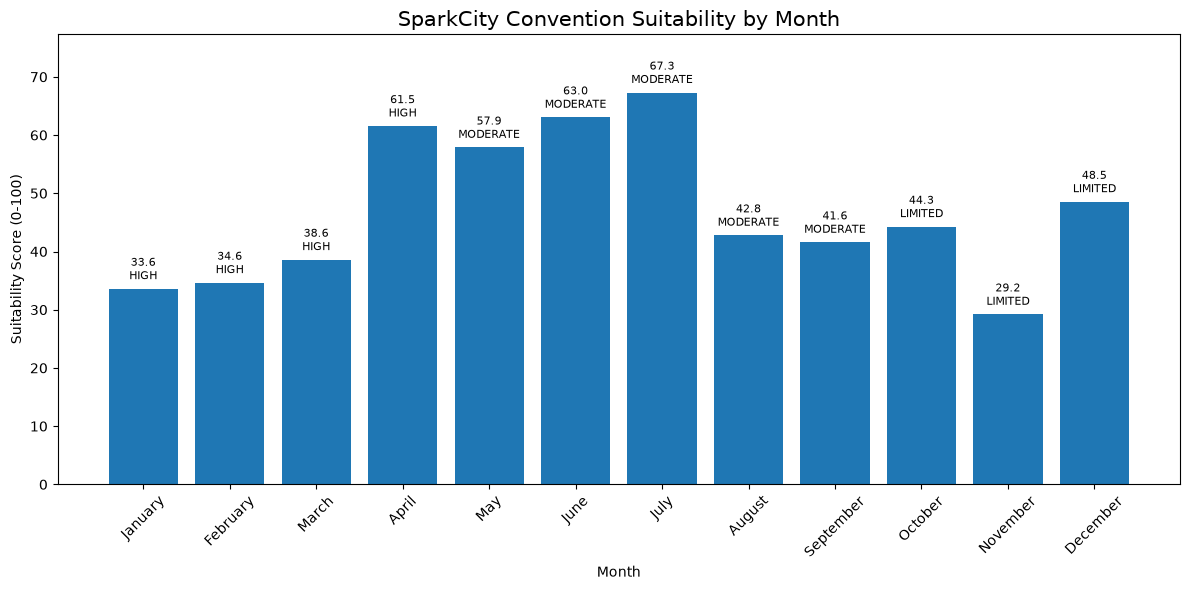

In [47]:
# ============================================================
# 10.1 CONVENTION SUITABILITY VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

suitability_chart_pd = (
    sensitivity_results
    .select(
        "month",
        "month_name",
        "business_weighted",
        "confidence"
    )
    .orderBy("month")
    .toPandas()
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    suitability_chart_pd["month_name"],
    suitability_chart_pd["business_weighted"]
)

plt.title(
    "SparkCity Convention Suitability by Month",
    fontsize=15
)

plt.xlabel("Month")
plt.ylabel("Suitability Score (0-100)")

plt.xticks(rotation=45)

plt.ylim(
    0,
    max(suitability_chart_pd["business_weighted"]) + 10
)

# Add score and confidence above each bar
for bar, score, confidence in zip(
    bars,
    suitability_chart_pd["business_weighted"],
    suitability_chart_pd["confidence"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{score:.1f}\n{confidence}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 10.2 Traffic Congestion and Alert Patterns

Traffic analysis showed that convention transportation risk is driven more strongly
by time of day than by month.

The following visualization summarizes traffic alert activity by hour to identify
periods when convention arrivals, departures, shuttle movements, and major events
should be minimized.

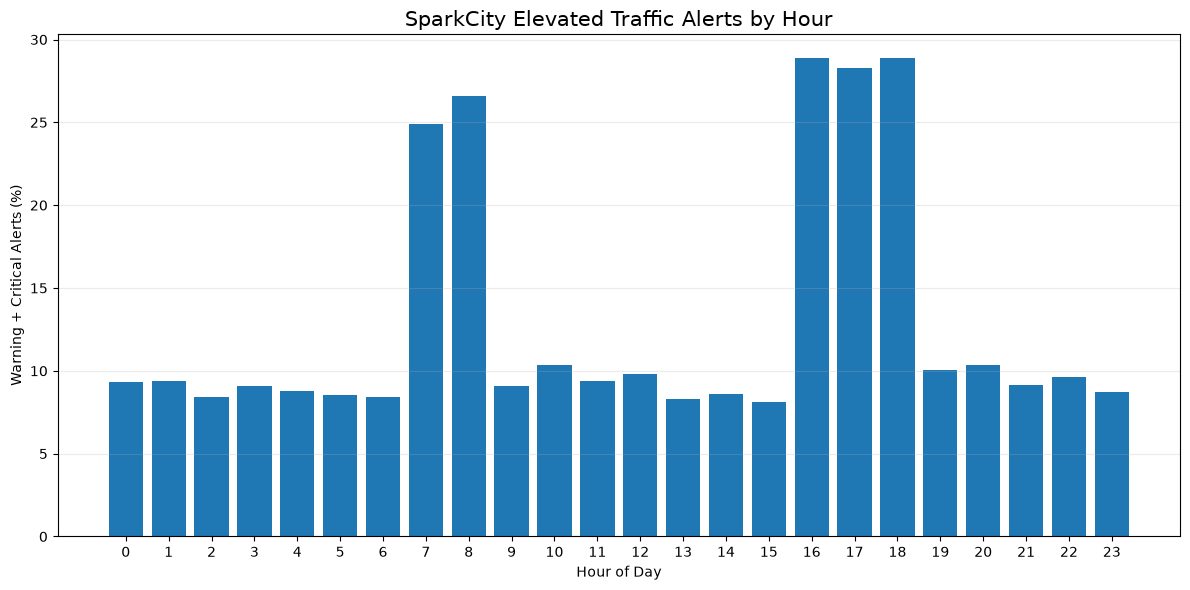

In [48]:
# ============================================================
# 10.2 TRAFFIC ALERTS BY HOUR
# ============================================================

# Re-create the previously defined WARNING/CRITICAL conditions
# from the original traffic feature DataFrame.
#
# Existing thresholds from Section 4:
# WARNING:
#   vehicle_count >= 75th percentile (101)
#   avg_speed <= 25th percentile (9.55)
#
# CRITICAL:
#   vehicle_count >= 90th percentile (119)
#   avg_speed <= 10th percentile (6.68)

traffic_alert_chart = (
    day4_datasets["traffic"]
    .withColumn("hour", F.hour("timestamp"))
    .withColumn(
        "elevated_alert",
        F.when(
            (
                (F.col("vehicle_count") >= 119)
                & (F.col("avg_speed") <= 6.68)
            )
            |
            (
                (F.col("vehicle_count") >= 101)
                & (F.col("avg_speed") <= 9.55)
            ),
            1
        ).otherwise(0)
    )
    .groupBy("hour")
    .agg(
        F.count("*").alias("total_observations"),
        F.sum("elevated_alert").alias("elevated_alerts")
    )
    .withColumn(
        "alert_rate_pct",
        F.round(
            (
                F.col("elevated_alerts")
                / F.col("total_observations")
            ) * 100,
            2
        )
    )
    .orderBy("hour")
)

traffic_alert_chart_pd = traffic_alert_chart.toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    traffic_alert_chart_pd["hour"],
    traffic_alert_chart_pd["alert_rate_pct"]
)

plt.title(
    "SparkCity Elevated Traffic Alerts by Hour",
    fontsize=15
)

plt.xlabel("Hour of Day")
plt.ylabel("Warning + Critical Alerts (%)")

plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

**Traffic Alert Interpretation**

Elevated WARNING and CRITICAL traffic conditions show a clear time-of-day pattern.

Alert rates increase sharply during the morning commute at approximately **7–8 AM**
and reach their highest levels during the afternoon commute at approximately
**4–6 PM**.

Outside these periods, elevated alert rates generally remain much lower.

For convention operations, SparkCity should avoid scheduling major attendee arrivals,
departures, shuttle movements, and other high-volume transportation activity during
these peak periods when possible.

This result also supports the decision not to use traffic as a major factor in selecting
the convention month. The strongest traffic pattern is associated with **hour of day**
rather than month of year.

### 10.3 Predictive Model Performance

The dashboard compares the three primary operational Random Forest models for traffic
volume, contemporaneous PM2.5 estimation, and energy demand.

Because the models predict different target variables with different units, RMSE and
MAE should not be compared directly across models. R² provides a high-level comparison
of how well each model explains variation in its respective target.

The separate next-observation PM2.5 forecasting model is evaluated in Section 5 and is
not included in this chart because it addresses a different future-time prediction
question.

**Predictive Model Interpretation**

The contemporaneous PM2.5 estimation and Energy Demand models show strong performance
in the SparkCity synthetic dataset, with R² values of 0.868 and 0.811. The separate
future PM2.5 forecast performed near the mean baseline (R² 0.001), so the strong
air-quality result should not be interpreted as evidence of reliable future forecasting.

The Traffic Volume model has R² 0.146 but improved over the chronological mean baseline,
reducing RMSE by approximately 7.6% and MAE by approximately 4.6%. Hour of day was the
dominant traffic predictor, which aligns with the commute-period patterns identified
elsewhere in the analysis.

Overall, same-time air-quality estimation and energy-demand modeling are useful with
the available synthetic features, while future air-quality forecasting and traffic
prediction would benefit from stronger sequential data and continued monitoring.

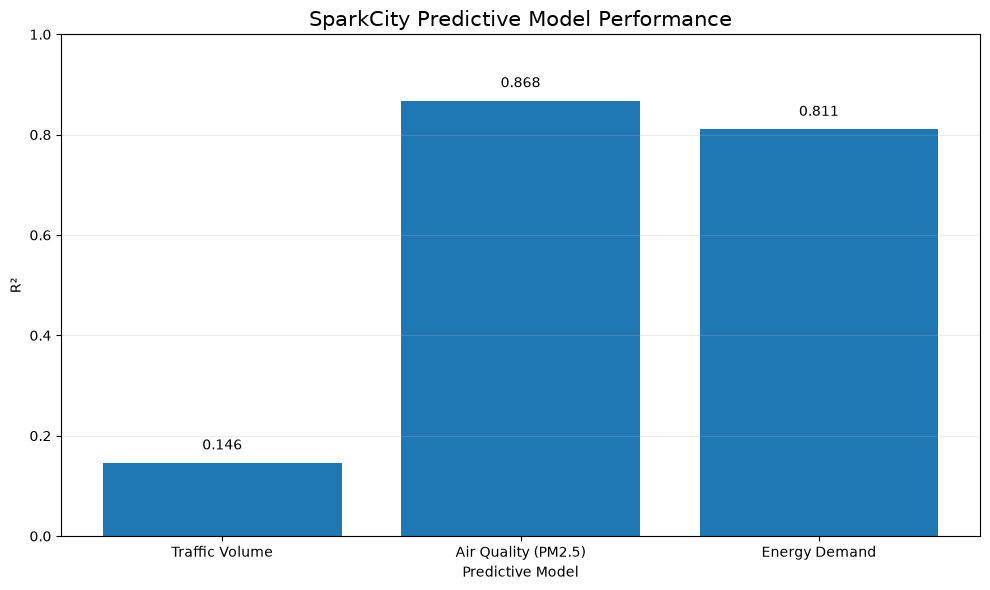

In [49]:
# ============================================================
# 10.3 PREDICTIVE MODEL PERFORMANCE
# ============================================================

model_performance_pd = pd.DataFrame({
    "Model": [
        "Traffic Volume",
        "Air Quality (PM2.5)",
        "Energy Demand"
    ],
    "R2": [
        0.146,
        0.868,
        0.811
    ]
})

plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_performance_pd["Model"],
    model_performance_pd["R2"]
)

plt.title(
    "SparkCity Predictive Model Performance",
    fontsize=15
)

plt.xlabel("Predictive Model")
plt.ylabel("R²")

plt.ylim(0, 1)

for bar, score in zip(
    bars,
    model_performance_pd["R2"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{score:.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

**Predictive Model Interpretation**

The Air Quality and Energy Demand models show strong predictive performance in the
SparkCity synthetic dataset, with R² values of 0.868 and 0.811 respectively.

The Traffic Volume model has a substantially lower R² of 0.146. However, it still
improved on the chronological mean baseline, reducing RMSE by approximately 7.6% and
MAE by approximately 4.6%.

Traffic feature analysis showed that hour of day was the dominant predictor of vehicle
volume. This aligns with the anomaly analysis, which identified clear morning and
afternoon commute peaks.

The results suggest that air quality and energy demand are relatively predictable from
the available features, while traffic behavior is more difficult to model and should
be supported by continued monitoring and real-time operational alerts.

### 10.4 Traffic Operating Profiles

KMeans clustering identified two distinct traffic sensor operating profiles.

The visualization compares average vehicle volume and average traffic speed for the
two clusters, helping city planners distinguish higher-congestion locations from
locations with better traffic flow.

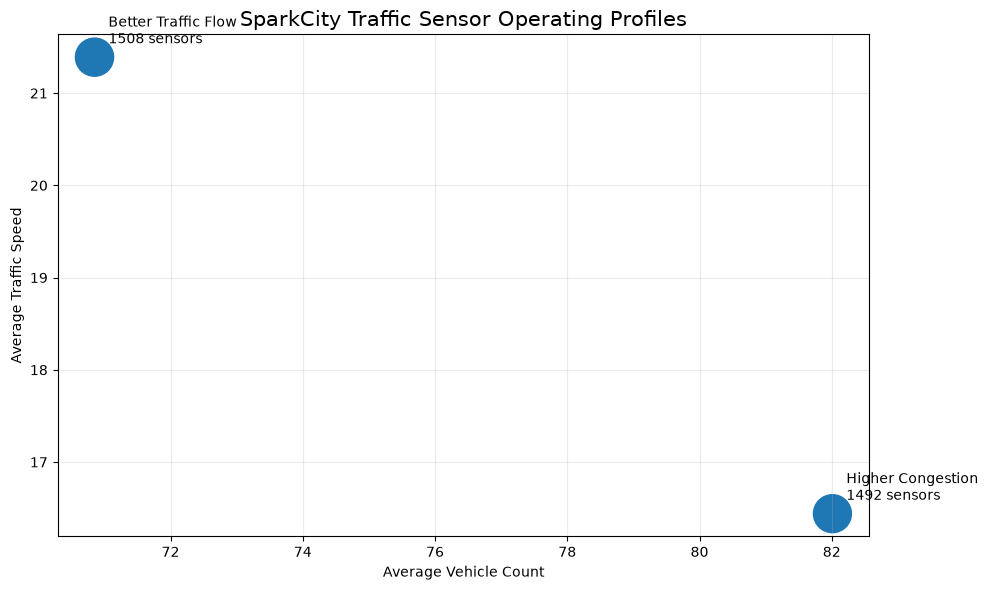

In [50]:
# ============================================================
# 10.4 TRAFFIC SENSOR CLUSTER VISUALIZATION
# ============================================================

traffic_cluster_chart_pd = pd.DataFrame({
    "Profile": [
        "Higher Congestion",
        "Better Traffic Flow"
    ],
    "Average Vehicle Count": [
        82.01,
        70.85
    ],
    "Average Speed": [
        16.44,
        21.39
    ],
    "Sensors": [
        1492,
        1508
    ]
})

plt.figure(figsize=(10, 6))

plt.scatter(
    traffic_cluster_chart_pd["Average Vehicle Count"],
    traffic_cluster_chart_pd["Average Speed"],
    s=traffic_cluster_chart_pd["Sensors"] / 2
)

for _, row in traffic_cluster_chart_pd.iterrows():
    plt.annotate(
        f'{row["Profile"]}\n{row["Sensors"]} sensors',
        (
            row["Average Vehicle Count"],
            row["Average Speed"]
        ),
        xytext=(10, 10),
        textcoords="offset points"
    )

plt.title(
    "SparkCity Traffic Sensor Operating Profiles",
    fontsize=15
)

plt.xlabel("Average Vehicle Count")
plt.ylabel("Average Traffic Speed")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Traffic Cluster Interpretation**

KMeans clustering identified two distinct traffic sensor operating profiles across
SparkCity.

The **Higher Congestion Profile** contains 1,492 sensors and is characterized by
higher average vehicle volume and lower average traffic speed.

The **Better Traffic Flow Profile** contains 1,508 sensors and is characterized by
lower average vehicle volume and higher average traffic speed.

The nearly even distribution of sensors between the two profiles suggests that
congestion conditions are not isolated to only a small number of locations.

For convention planning, these clusters can support route selection, shuttle planning,
traffic-control placement, and identification of locations that may require additional
transportation management.

## 11. Operational Anomaly Scoring and Automated Triggers

The Day 4 anomaly analysis identified unusual traffic behavior using Isolation Forest
and created operational WARNING and CRITICAL thresholds based on the observed SparkCity
traffic distribution.

SparkCity currently uses static historical data rather than a live streaming source.
Therefore, this section demonstrates a **near-real-time scoring workflow** by treating
a small batch of traffic observations as newly arriving records.

The workflow demonstrates how future incoming traffic data could be:

1. Evaluated against established traffic thresholds.
2. Assigned an operational alert level.
3. Associated with a recommended response.
4. Routed for investigation when conditions become severe.

This is a simulation of an operational scoring workflow and should not be interpreted
as a deployed real-time streaming system.

In [51]:
# ============================================================
# 11.1 REUSABLE TRAFFIC ALERT SCORING
# ============================================================

def score_traffic_alerts(df):
    """
    Apply SparkCity traffic alert thresholds to a Spark DataFrame.

    CRITICAL:
        vehicle_count >= 119 AND avg_speed <= 6.68

    WARNING:
        vehicle_count >= 101 AND avg_speed <= 9.55

    NORMAL:
        all other observations
    """

    return (
        df
        .withColumn(
            "alert_level",
            F.when(
                (F.col("vehicle_count") >= 119)
                & (F.col("avg_speed") <= 6.68),
                "CRITICAL"
            )
            .when(
                (F.col("vehicle_count") >= 101)
                & (F.col("avg_speed") <= 9.55),
                "WARNING"
            )
            .otherwise("NORMAL")
        )
        .withColumn(
            "recommended_action",
            F.when(
                F.col("alert_level") == "CRITICAL",
                "Immediate traffic operations review"
            )
            .when(
                F.col("alert_level") == "WARNING",
                "Monitor conditions and prepare response"
            )
            .otherwise(
                "Continue routine monitoring"
            )
        )
    )


print("Traffic alert scoring function created successfully.")

Traffic alert scoring function created successfully.


### 11.2 Simulated Incoming Traffic Batch

To demonstrate the operational workflow, a small set of simulated traffic observations
is treated as newly arriving data.

The sample intentionally includes normal, warning, and critical traffic conditions so
that the alert-scoring logic and recommended responses can be verified.

These records are demonstration data only and are not written to the SparkCity
PostgreSQL database.

In [52]:
# ============================================================
# 11.2 SIMULATE INCOMING TRAFFIC AND TRIGGER ALERTS
# ============================================================

incoming_traffic_data = [
    ("SIM-001", 75, 22.0),
    ("SIM-002", 105, 8.5),
    ("SIM-003", 125, 5.5),
    ("SIM-004", 95, 12.0),
    ("SIM-005", 130, 6.0)
]

incoming_traffic_schema = [
    "sensor_id",
    "vehicle_count",
    "avg_speed"
]

incoming_traffic = spark.createDataFrame(
    incoming_traffic_data,
    incoming_traffic_schema
)

scored_incoming_traffic = score_traffic_alerts(
    incoming_traffic
)

print("=" * 90)
print("SIMULATED NEAR-REAL-TIME TRAFFIC SCORING")
print("=" * 90)

scored_incoming_traffic.select(
    "sensor_id",
    "vehicle_count",
    "avg_speed",
    "alert_level",
    "recommended_action"
).show(
    truncate=False
)

SIMULATED NEAR-REAL-TIME TRAFFIC SCORING
+---------+-------------+---------+-----------+---------------------------------------+
|sensor_id|vehicle_count|avg_speed|alert_level|recommended_action                     |
+---------+-------------+---------+-----------+---------------------------------------+
|SIM-001  |75           |22.0     |NORMAL     |Continue routine monitoring            |
|SIM-002  |105          |8.5      |WARNING    |Monitor conditions and prepare response|
|SIM-003  |125          |5.5      |CRITICAL   |Immediate traffic operations review    |
|SIM-004  |95           |12.0     |NORMAL     |Continue routine monitoring            |
|SIM-005  |130          |6.0      |CRITICAL   |Immediate traffic operations review    |
+---------+-------------+---------+-----------+---------------------------------------+



### 11.3 Automated Trigger and Investigation Workflow

After incoming traffic observations are scored, SparkCity can automatically identify
records requiring operational attention.

The prototype uses the following trigger workflow:

- **NORMAL** — Continue routine monitoring. No investigation is created.
- **WARNING** — Add the condition to the traffic operations review queue.
- **CRITICAL** — Escalate the condition for immediate traffic operations review.

In a production environment, these triggers could be integrated with dashboards,
notification services, incident-management systems, or streaming infrastructure.

The current implementation demonstrates the decision logic only. It does not send
external notifications or create production incidents.

In [53]:
# ============================================================
# 11.3 AUTOMATED INVESTIGATION TRIGGER WORKFLOW
# ============================================================

traffic_investigation_queue = (
    scored_incoming_traffic
    .filter(
        F.col("alert_level").isin(
            "WARNING",
            "CRITICAL"
        )
    )
    .withColumn(
        "priority",
        F.when(
            F.col("alert_level") == "CRITICAL",
            1
        ).otherwise(2)
    )
    .withColumn(
        "workflow_status",
        F.lit("OPEN")
    )
    .withColumn(
        "investigation_reason",
        F.when(
            F.col("alert_level") == "CRITICAL",
            "Very high traffic volume combined with very low speed"
        ).otherwise(
            "Elevated traffic volume combined with reduced speed"
        )
    )
    .orderBy(
        "priority",
        F.desc("vehicle_count")
    )
)

print("=" * 100)
print("AUTOMATED TRAFFIC INVESTIGATION QUEUE")
print("=" * 100)

traffic_investigation_queue.select(
    "priority",
    "sensor_id",
    "vehicle_count",
    "avg_speed",
    "alert_level",
    "workflow_status",
    "investigation_reason",
    "recommended_action"
).show(
    truncate=False
)

trigger_count = traffic_investigation_queue.count()
critical_count = (
    traffic_investigation_queue
    .filter(F.col("alert_level") == "CRITICAL")
    .count()
)
warning_count = (
    traffic_investigation_queue
    .filter(F.col("alert_level") == "WARNING")
    .count()
)

print(f"Triggered investigations: {trigger_count}")
print(f"Critical escalations:     {critical_count}")
print(f"Warning reviews:          {warning_count}")

AUTOMATED TRAFFIC INVESTIGATION QUEUE
+--------+---------+-------------+---------+-----------+---------------+-----------------------------------------------------+---------------------------------------+
|priority|sensor_id|vehicle_count|avg_speed|alert_level|workflow_status|investigation_reason                                 |recommended_action                     |
+--------+---------+-------------+---------+-----------+---------------+-----------------------------------------------------+---------------------------------------+
|1       |SIM-005  |130          |6.0      |CRITICAL   |OPEN           |Very high traffic volume combined with very low speed|Immediate traffic operations review    |
|1       |SIM-003  |125          |5.5      |CRITICAL   |OPEN           |Very high traffic volume combined with very low speed|Immediate traffic operations review    |
|2       |SIM-002  |105          |8.5      |WARNING    |OPEN           |Elevated traffic volume combined with reduced speed  |M

## 12. Day 4 Validation and Deliverables

Day 4 extends the SparkCity analytical pipeline from exploratory and feature engineering
work into advanced analytics, predictive modeling, operational monitoring, optimization,
and decision support.

The following checklist validates the completed Day 4 deliverables.

### Anomaly Detection and Operational Monitoring

- Isolation Forest anomaly detection implemented for traffic conditions.
- Distribution-based WARNING and CRITICAL thresholds established.
- Anomalies separated from operational alerts so unusual behavior is not automatically
  treated as an emergency.
- Reusable traffic alert-scoring function implemented.
- Simulated near-real-time incoming traffic batch scored.
- Automated investigation queue demonstrated.
- WARNING conditions routed for review.
- CRITICAL conditions prioritized for immediate operational review.

### Predictive Modeling

Predictive modeling was completed for traffic volume, air quality, and energy demand.
Air quality was evaluated using both a contemporaneous PM2.5 estimation model and a
separate future PM2.5 forecasting model. All predictive models were evaluated using
chronological train/test splits and compared with baseline performance.

- **Traffic Volume Prediction**
  - R²: 0.146
  - RMSE: 33.534
  - MAE: 28.176
  - Improved RMSE approximately 7.6% over the mean baseline.

- **Air Quality Modeling and Forecasting**
  - Contemporaneous PM2.5 estimation achieved:
    - R²: 0.868
    - RMSE: 2.965
    - MAE: 2.463
  - PM10 was the dominant predictor of contemporaneous PM2.5.
  - A separate future forecasting pipeline was developed to predict the next available
    PM2.5 observation for each sensor.
  - Future forecast performance:
    - R²: 0.001
    - RMSE: 8.126
    - MAE: 6.997
  - The future model improved RMSE only 0.04% and MAE 0.11% over the mean baseline.
  - The current synthetic dataset therefore supports strong contemporaneous PM2.5
    estimation but does not support reliable future PM2.5 forecasting.
  - Sparse sequential observations per sensor limit the usefulness of the future
    forecasting model.

- **Energy Demand Prediction**
  - R²: 0.811
  - RMSE: 9.547
  - MAE: 6.967
  - Improved substantially over the mean baseline.

### Spark Pipeline Optimization

- Baseline aggregation performance benchmarked.
- Caching tested for repeated analytical workloads.
- Cached repeated aggregation was approximately 51% faster than the uncached repeated
  query after cache materialization.
- Repartitioning from 2 to 6 partitions was tested.
- Repartitioning was approximately 59% slower for this small workload.
- Adaptive Query Execution and partition coalescing verified as enabled.
- Optimization recommendations were based on measured workload performance rather than
  assuming that additional partitions always improve execution.

### Advanced Analytics

- KMeans clustering evaluated for k=2 through k=6.
- k=2 produced the strongest silhouette score.
- 3,000 traffic sensors were grouped into:
  - Higher Congestion Profile
  - Better Traffic Flow Profile
- Cluster results support transportation routing and city-planning decisions.

### Convention Decision Support

- Coverage-aware monthly convention baseline created.
- Capacity, fiscal conditions, air quality, and weather incorporated into suitability
  analysis.
- Traffic and energy retained as operational planning factors rather than allowing
  limited monthly variation to distort month selection.
- Suitability and data confidence maintained as separate measures.
- Three weighting scenarios tested through sensitivity analysis.
- July ranked #1 under all three scenarios.
- April identified as the strongest high-confidence alternative.
- Operational recommendations incorporated traffic scheduling, congestion monitoring,
  air-quality monitoring, energy planning, and lodging capacity.

### Advanced Analytics Dashboard

The notebook includes visual decision support for:

- Convention suitability by month.
- Elevated traffic alerts by hour.
- Predictive model performance.
- Traffic sensor operating profiles.

### Key Limitations and Interpretation Notes

- **Synthetic data:** SparkCity uses synthetic data, so model performance and observed
  relationships should not be assumed to represent real-world city behavior without
  validation against production data.

- **Uneven temporal coverage:** Traffic data ends in early May and energy data ends in
  early September. Some year-month periods are partial, so monthly comparisons do not
  all represent identical observation windows.

- **Convention confidence:** July ranked first in all three convention suitability
  scenarios, but it has MODERATE confidence because traffic data is unavailable for
  that month. April is the strongest HIGH-confidence alternative.

- **Air-quality forecasting:** The contemporaneous PM2.5 estimation model performed
  strongly, but the true future PM2.5 forecast performed approximately the same as the
  baseline. Sparse observations for individual sensors limit future forecasting.

- **Temperature units:** Temperature was excluded from the convention suitability score
  because the observed values and documented unit labeling were not sufficiently
  consistent to support an absolute comfort threshold confidently.

- **Anomaly interpretation:** Isolation Forest identifies statistically unusual
  observations, not necessarily dangerous conditions. Separate operational thresholds
  were therefore used for WARNING and CRITICAL traffic alerts.

- **Convention scoring:** Min-max normalization can magnify small differences in
  relatively stable variables. Category weighting and sensitivity analysis were used
  to reduce dependence on any single scoring assumption.

- **Operational prototype:** Near-real-time scoring and automated triggers are
  demonstrated using simulated incoming records. The notebook does not implement a
  production streaming or external notification system.

- **Optimization benchmarks:** Performance tests were conducted on the local Spark
  environment and relatively small SparkCity datasets. Results are workload-specific
  and should be re-benchmarked at production scale.

### Day 4 Status

**Day 4 advanced analytics requirements are implemented and validated.**

The results provide both technical analytics and actionable decision support for
SparkCity leadership while documenting important limitations in data coverage,
synthetic-data behavior, and model interpretation.

## 13. Final Convention Recommendation — Java Team Handoff

### Recommended Convention Month: JULY

SparkCity's advanced analytics identify **July** as the preferred month for the
convention.

**July Suitability Score:** 67.3 / 100  
**Overall Rank:** #1  
**Data Confidence:** MODERATE

July ranked first under all three weighting scenarios tested:

- Business-focused weighting: #1
- Equal weighting: #1
- Attendee-focused weighting: #1

July performs well because of the combined results for lodging capacity, existing
economic conditions, air quality, and precipitation.

### High-Confidence Alternative: APRIL

**April Suitability Score:** 61.54 / 100  
**Overall Business-Weighted Rank:** #3  
**Data Confidence:** HIGH

April is the strongest alternative when complete data coverage is prioritized.
All six analytical datasets are represented during April, and April remained near
the top across the sensitivity-analysis scenarios.

### Operational Guidance for the Convention

The month recommendation should be combined with operational planning rather than
using month alone.

**Traffic**
- Avoid major attendee transportation during **7–8 AM**.
- Avoid major attendee transportation during **4–6 PM**.
- Use traffic alerts and sensor congestion profiles for routing and shuttle planning.

**Air Quality**
- Monitor current PM2.5 conditions during the event.
- The contemporaneous PM2.5 model performs strongly (R² = 0.868).
- The future PM2.5 forecasting model does not outperform the baseline meaningfully,
  so it should not be used as a reliable long-range forecast.

**Energy**
- Energy demand is predictable operationally (R² = 0.811).
- Monthly energy variation is small, so energy demand should support operational
  planning rather than determine the convention month.

### Dashboard Recommendation

The Java dashboard should communicate:

**BEST MONTH:** July  
**SUITABILITY SCORE:** 67.3 / 100  
**CONFIDENCE:** Moderate  
**HIGH-CONFIDENCE ALTERNATIVE:** April  
**APRIL SCORE:** 61.54 / 100  

**TRAFFIC ADVISORY:** Avoid 7–8 AM and 4–6 PM for major attendee transportation.

### Important Interpretation

July is the analytical recommendation, but its confidence is MODERATE because traffic
data is unavailable after early May. April should therefore be presented alongside
July as the strongest option when complete data coverage is preferred.

The recommendation is based on synthetic SparkCity data and should be treated as
decision support rather than a causal prediction of convention outcomes.

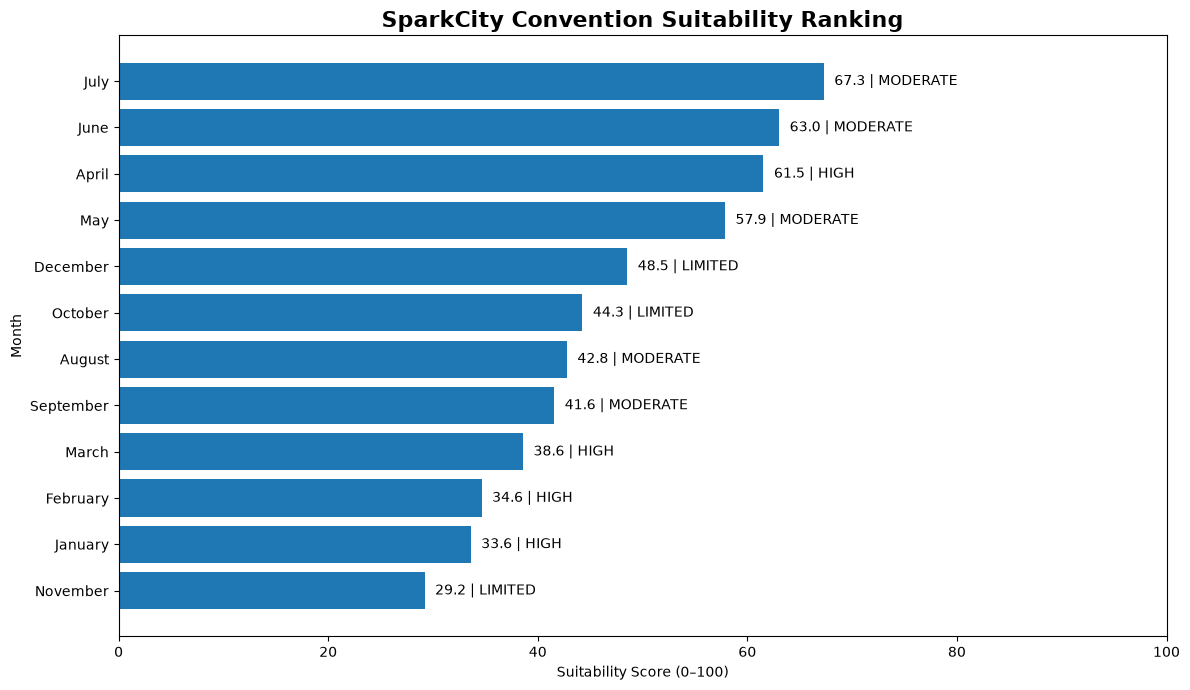

In [58]:
# ============================================================
# 13.1 FINAL CONVENTION RECOMMENDATION VISUAL
# ============================================================

final_convention_results = pd.DataFrame({
    "month": [
        "July", "June", "April", "May",
        "December", "October", "August", "September",
        "March", "February", "January", "November"
    ],
    "score": [
        67.30, 63.04, 61.54, 57.87,
        48.54, 44.26, 42.78, 41.57,
        38.59, 34.64, 33.60, 29.20
    ],
    "confidence": [
        "MODERATE", "MODERATE", "HIGH", "MODERATE",
        "LIMITED", "LIMITED", "MODERATE", "MODERATE",
        "HIGH", "HIGH", "HIGH", "LIMITED"
    ]
})

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    final_convention_results["month"],
    final_convention_results["score"]
)

ax.invert_yaxis()

ax.set_title(
    "SparkCity Convention Suitability Ranking",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Suitability Score (0–100)")
ax.set_ylabel("Month")
ax.set_xlim(0, 100)

for bar, score, confidence in zip(
    bars,
    final_convention_results["score"],
    final_convention_results["confidence"]
):
    ax.text(
        score + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.1f} | {confidence}",
        va="center"
    )

plt.tight_layout()
plt.show()

### 13.2 Why July Ranks First

July does not rank first because of a single dominant factor. Instead, it provides the
strongest overall balance across convention capacity, fiscal conditions, air quality,
and weather.

April has the strongest weather score but substantially lower air-quality performance.
June has the strongest fiscal score but weaker capacity and weather scores. July
performs comparatively well across all four categories, producing the highest overall
weighted suitability score.

Because traffic data is unavailable for July, the July recommendation carries MODERATE
confidence. April remains the strongest HIGH-confidence alternative.

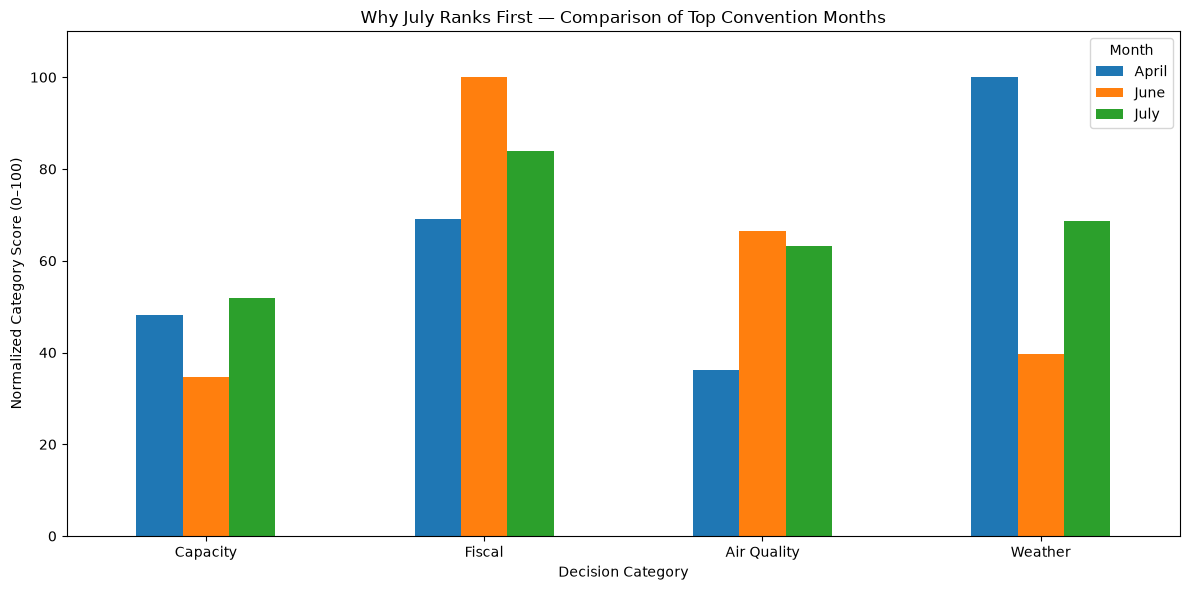

In [55]:
# 13.2 WHY JULY RANKS FIRST — TOP CONTENDERS BY DECISION CATEGORY

top_months_pd = (
    convention_category_scores
    .filter(F.col("month").isin(4, 6, 7))
    .select(
        "month",
        "capacity_score",
        "fiscal_score",
        "air_quality_score",
        "weather_score"
    )
    .orderBy("month")
    .toPandas()
)

month_names = {
    4: "April",
    6: "June",
    7: "July"
}

top_months_pd["month_name"] = top_months_pd["month"].map(month_names)

category_columns = [
    "capacity_score",
    "fiscal_score",
    "air_quality_score",
    "weather_score"
]

category_labels = [
    "Capacity",
    "Fiscal",
    "Air Quality",
    "Weather"
]

chart_data = top_months_pd.set_index("month_name")[category_columns].T
chart_data.index = category_labels

ax = chart_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Why July Ranks First — Comparison of Top Convention Months")
ax.set_xlabel("Decision Category")
ax.set_ylabel("Normalized Category Score (0–100)")
ax.set_ylim(0, 110)
ax.legend(title="Month")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 13.3 Java Team Convention Recommendation Handoff

The above table provides the final convention recommendation in a simplified
structure for use by the Java team in the SparkCity dashboard.

The dashboard should identify **July as the primary recommendation** and **April as the
high-confidence alternative**. Confidence reflects the completeness of the available
analytical datasets and should be displayed separately from the suitability score.

In [56]:
# 13.3 JAVA TEAM CONVENTION RECOMMENDATION HANDOFF

from pyspark.sql import functions as F
from pyspark.sql.window import Window

ranking_window = Window.orderBy(F.desc("suitability_score"))

java_convention_handoff = (
    convention_suitability
    .withColumn(
        "rank",
        F.row_number().over(ranking_window)
    )
    .withColumn(
        "recommendation",
        F.when(F.col("month_name") == "July", "PRIMARY")
         .when(F.col("month_name") == "April", "HIGH-CONFIDENCE ALTERNATIVE")
         .otherwise("OTHER")
    )
    .select(
        "rank",
        "month",
        "month_name",
        F.round("suitability_score", 2).alias("suitability_score"),
        "confidence",
        "recommendation",
        "coverage_note"
    )
    .orderBy("rank")
)

print("=" * 100)
print("JAVA TEAM — CONVENTION RECOMMENDATION HANDOFF")
print("=" * 100)

java_convention_handoff.show(12, truncate=False)

JAVA TEAM — CONVENTION RECOMMENDATION HANDOFF


26/09/15 15:17:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 1

+----+-----+----------+-----------------+----------+---------------------------+----------------------------------------------+
|rank|month|month_name|suitability_score|confidence|recommendation             |coverage_note                                 |
+----+-----+----------+-----------------+----------+---------------------------+----------------------------------------------+
|1   |7    |July      |67.3             |MODERATE  |PRIMARY                    |No traffic data available                     |
|2   |6    |June      |63.04            |MODERATE  |OTHER                      |No traffic data available                     |
|3   |4    |April     |61.54            |HIGH      |HIGH-CONFIDENCE ALTERNATIVE|Complete coverage across all six datasets     |
|4   |5    |May       |57.87            |MODERATE  |OTHER                      |Traffic data available only through May 5     |
|5   |12   |December  |48.54            |LIMITED   |OTHER                      |No traffic or energy dat

26/09/15 15:17:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


### 13.4 Java-Ready Recommendation Data

The final recommendation is also represented as JSON so the dashboard team can consume
the analytical results without reproducing the scoring logic in Java. The Python/Spark
analysis remains the source of truth for the convention recommendation.

In [57]:
# 13.4 JAVA-READY CONVENTION RECOMMENDATION JSON

import json

java_handoff_records = [
    json.loads(row)
    for row in java_convention_handoff.toJSON().collect()
]

java_handoff_json = json.dumps(
    java_handoff_records,
    indent=2
)

print(java_handoff_json)

/Users/leigh/Projects/SparkCity_Capstone/.venv/lib/python3.13/site-packages/pyspark/sql/classic/dataframe.py:178: UserWarning: The return type of DataFrame.toJSON will be changed from RDD to DataFrame in future releases.
  warnings.warn(
26/09/15 15:17:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/15 15:17:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a sin

[
  {
    "rank": 1,
    "month": 7,
    "month_name": "July",
    "suitability_score": 67.3,
    "confidence": "MODERATE",
    "recommendation": "PRIMARY",
    "coverage_note": "No traffic data available"
  },
  {
    "rank": 2,
    "month": 6,
    "month_name": "June",
    "suitability_score": 63.04,
    "confidence": "MODERATE",
    "recommendation": "OTHER",
    "coverage_note": "No traffic data available"
  },
  {
    "rank": 3,
    "month": 4,
    "month_name": "April",
    "suitability_score": 61.54,
    "confidence": "HIGH",
    "recommendation": "HIGH-CONFIDENCE ALTERNATIVE",
    "coverage_note": "Complete coverage across all six datasets"
  },
  {
    "rank": 4,
    "month": 5,
    "month_name": "May",
    "suitability_score": 57.87,
    "confidence": "MODERATE",
    "recommendation": "OTHER",
    "coverage_note": "Traffic data available only through May 5"
  },
  {
    "rank": 5,
    "month": 12,
    "month_name": "December",
    "suitability_score": 48.54,
    "confidence":

### Final Decision

**July is the recommended convention month.**

July achieved the highest overall suitability score (**67.3**) and ranked #1 under
all three weighting scenarios tested. Its confidence is **MODERATE** because traffic
data is unavailable for July.

**April is the recommended high-confidence alternative.** April scored **61.54** and
has **HIGH** confidence because all six analytical datasets are represented during
that period.

The Java dashboard should therefore present July as the primary recommendation while
also displaying April as the strongest option when complete data coverage is preferred.